In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 

df_train = pd.read_csv('train_set.csv')
df_test =  pd.read_csv('test_set.csv')

# Function to calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def run_model_with_top_features_and_qq_plot(df_train, df_test, model, param_grid,  selected_features, model_name="Model"):

    # Separate features and target variable in training and test datasets
    X_train = df_train[selected_features]  # Replace 'Cost_claims_year' if different
    y_train = df_train['Cost_claims_year']
    X_test = df_test[selected_features]
    y_test = df_test['Cost_claims_year']

    # Nested cross-validation with hyperparameter tuning
    def hyperparameter_tuning_with_nested_cv(model, param_grid, X_train, y_train):
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

        fold_metrics = []  # To store metrics for each fold

        for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
            X_fold_train, X_fold_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
            y_fold_train, y_fold_valid = y_train.iloc[train_idx], y_train.iloc[valid_idx]

            # Run hyperparameter tuning on the training fold
            grid_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                cv=inner_cv,
                n_jobs=-1,
                scoring='neg_mean_squared_error',
                random_state=42
            )
            grid_search.fit(X_fold_train, y_fold_train)

            # Use the best model to predict the validation fold
            best_model = grid_search.best_estimator_
            y_pred_valid = best_model.predict(X_fold_valid)

            # Calculate metrics for the validation fold
            mse_fold = mean_squared_error(y_fold_valid, y_pred_valid)
            mae_fold = mean_absolute_error(y_fold_valid, y_pred_valid)

            # Print metrics for the fold
            print(f"Fold {fold} Results:")
            print(f"  Mean Squared Error (MSE): {mse_fold:.4f}")
            print(f"  Mean Absolute Error (MAE): {mae_fold:.4f}")

            # Store metrics for summary
            fold_metrics.append((fold, mse_fold, mae_fold))

        # After cross-validation, refit on the entire training set and return the best model
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

        return best_model, best_params, fold_metrics

    # Run nested CV and get the best model and fold metrics
    best_model, best_params, fold_metrics = hyperparameter_tuning_with_nested_cv(
        model, param_grid, X_train, y_train
    )

    print(f"\nBest Parameters from Grid Search for {model_name}:\n{best_params}\n")

    # Summary of metrics across folds
    print(f"\n{model_name} Cross-Validation Summary:")
    for fold, mse_fold, mae_fold in fold_metrics:
        print(f"  Fold {fold}: MSE = {mse_fold:.4f}, MAE = {mae_fold:.4f}")

    # Evaluate the model on the full test set
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Calculate metrics for training and testing
    mse_train = mean_squared_error(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Print evaluation results
    print(f"\n{model_name} Model Evaluation on Training Set:")
    print(f"Mean Squared Error (MSE - Training): {mse_train:.4f}")
    print(f"Mean Absolute Error (MAE - Training, Log Transformed): {mae_train:.4f}")
    print(f"R² Score (Training): {r2_train:.4f}")

    print(f"\n{model_name} Model Evaluation on Test Set:")
    print(f"Mean Squared Error (MSE - Testing): {mse_test:.4f}")
    print(f"Mean Absolute Error (MAE - Testing, Log Transformed): {mae_test:.4f}")
    print(f"R² Score (Testing): {r2_test:.4f}")

     # Convert log-transformed predictions and true values back to their original scale
    df_train['y_true'] = y_train.copy()  # Ensure it's a copy of y_test
    df_train['y_pred'] = y_pred_train
    df_train['y_pred_nolog'] = np.expm1(y_pred_train)  # Predicted values in original scale
    df_train['y_true_nolog'] = np.expm1(y_train) 
    mae_train_exp = mean_absolute_error(df_train['y_true_nolog'], df_train['y_pred_nolog'])
    mape_train_exp = mean_absolute_percentage_error(df_train['y_true_nolog'], df_train['y_pred_nolog'])
    print(f"Mean Absolute Percentage Error (MAPE - Training, Original Scale): {mape_train_exp:.4f}")
    print(f"Mean Absolute Error (MAE - Training, Original Scale): {mae_train_exp:.4f}")

    # Convert log-transformed predictions and true values back to their original scale
    df_test['y_true'] = y_test.copy()  # Ensure it's a copy of y_test
    df_test['y_pred'] = y_pred_test
    df_test['y_pred_nolog'] = np.expm1(y_pred_test)  # Predicted values in original scale
    df_test['y_true_nolog'] = np.expm1(y_test)     
    mae_test_exp = mean_absolute_error(df_test['y_true_nolog'], df_test['y_pred_nolog'])
    mape_test_exp = mean_absolute_percentage_error(df_test['y_true_nolog'], df_test['y_pred_nolog'])
    print(f"Mean Absolute Percentage Error (MAPE - Testing, Original Scale): {mape_test_exp:.4f}")
    print(f"Mean Absolute Error (MAE - Testing, Original Scale): {mae_test_exp:.4f}")

    # Store results in new DataFrames
    train_results = df_train.copy()
    test_results = df_test.copy()

    # Add predictions and residuals to DataFrames
    train_results['y_true'] = y_train
    train_results['y_pred'] = y_pred_train
    train_results['residuals'] = y_train - y_pred_train

    test_results['y_true'] = y_test
    test_results['y_pred'] = y_pred_test
    test_results['residuals'] = y_test - y_pred_test

    # Save results
    train_results.to_csv(f"{model_name.lower().replace(' ', '_')}_train__SHAPtune1K.csv", index=False)
    test_results.to_csv(f"{model_name.lower().replace(' ', '_')}_test_SHAPtune1K.csv", index=False)


    # Plot Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor", fontsize=14)
    plt.xlabel("Actual Cost Claims Year", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

     # Plot Actual vs Predicted using original scale
    plt.figure(figsize=(10, 6))
    plt.scatter(np.exp(y_test), np.exp(y_pred_test), alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([np.exp(y_test).min(), np.exp(y_test).max()], 
             [np.exp(y_test).min(), np.exp(y_test).max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor (Original Scale)", fontsize=14)
    plt.xlabel("Actual Cost Claims Year (Original Scale)", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year (Original Scale)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    # Plot Q-Q Plot for Residuals
    plt.figure(figsize=(8, 8))
    stats.probplot(residuals_test, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {model_name} Residuals", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    # Plot residuals and prediction density
    plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_prediction_kde(y_pred_train, y_pred_test, model_name)
    compute_cooks_and_leverage(X_test, y_test, y_pred_test, model_name, df_test)

    return best_model
# Density plot of residuals
def plot_residual_density(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    train_residuals, test_residuals = y_train_true - y_train_pred, y_test_true - y_test_pred
    plt.figure(figsize=(10, 6))
    sns.kdeplot(train_residuals, color='blue', fill=True, label='Train Residuals')
    sns.kdeplot(test_residuals, color='green', fill=True, label='Test Residuals')
    plt.title(f'Density Plot of Residuals for {model_name} (Claim Severity)')
    plt.xlabel('Residuals')
    plt.legend()
    plt.show()

# Density plot of predictions
def plot_prediction_kde(y_train_pred, y_test_pred, model_name):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_train_pred, color='blue', fill=True, label='Train Predictions')
    sns.kdeplot(y_test_pred, color='green', fill=True, label='Test Predictions')
    plt.title(f'Kernel Density Plot of Predictions for {model_name} (Claim Severity)')
    plt.xlabel('Predicted Values')
    plt.legend()
    plt.show()

# Function to compute Cook's distance and leverage
def compute_cooks_and_leverage(X, y_true, y_pred, model_name, df):
    residuals = y_true - y_pred
    X_with_const = sm.add_constant(X)
    linear_model = sm.OLS(residuals, X_with_const).fit()
    influence = OLSInfluence(linear_model)
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]
    leverage_threshold = 3 * np.mean(leverage)
    cooks_threshold = 4 / len(cooks_d)
    high_leverage_points = np.where(leverage > leverage_threshold)[0]
    high_cooks_points = np.where(cooks_d > cooks_threshold)[0]
    ids_high_leverage = df.loc[high_leverage_points, 'ID'].tolist()
    ids_high_cooks = df.loc[high_cooks_points, 'ID'].tolist()
    print(f"High leverage points IDs: {ids_high_leverage}")
    print(f"High Cook's distance points IDs: {ids_high_cooks}")
    return cooks_d, leverage, ids_high_leverage, ids_high_cooks

def plot_residuals_and_qq(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    train_residuals, test_residuals = y_train_true - y_train_pred, y_test_true - y_test_pred
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    sns.scatterplot(x=y_train_pred, y=train_residuals, color='blue', ax=ax1, label=f'Train MAPE = {mean_absolute_percentage_error(y_train_true, y_train_pred):.3f}')
    sns.scatterplot(x=y_test_pred, y=test_residuals, color='green', ax=ax1, label=f'Test MAPE = {mean_absolute_percentage_error(y_test_true, y_test_pred):.3f}')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_title(f'Residuals for {model_name} Model (Claim Severity)')
    stats.probplot(train_residuals, dist="norm", plot=ax2)
    stats.probplot(test_residuals, dist="norm", plot=ax2)
    plt.tight_layout()
    plt.show()



c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2541
  Mean Absolute Error (MAE): 0.1828


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2729
  Mean Absolute Error (MAE): 0.1903


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2603
  Mean Absolute Error (MAE): 0.1861


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2596
  Mean Absolute Error (MAE): 0.1869


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for XGBoost Regressor:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


XGBoost Regressor Cross-Validation Summary:
  Fold 1: MSE = 0.2541, MAE = 0.1828
  Fold 2: MSE = 0.2729, MAE = 0.1903
  Fold 3: MSE = 0.2553, MAE = 0.1835
  Fold 4: MSE = 0.2603, MAE = 0.1861
  Fold 5: MSE = 0.2596, MAE = 0.1869

XGBoost Regressor Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2554
Mean Absolute Error (MAE - Training, Log Transformed): 0.1844
R² Score (Training): 0.9480

XGBoost Regressor Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2632
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1834
R² Score (Testing): 0.9450
Mean Absolute Percentage Error (MAPE - Training, Original Scale): inf
Mean Absolute Error (MAE - Training, Original Scale): 116.9761
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): inf
Mean Absolute Error (MAE - Testing, Orig

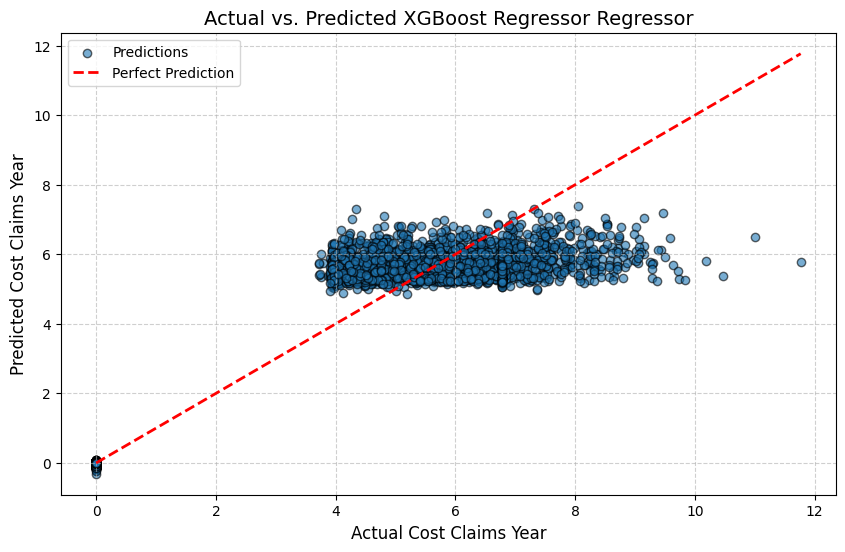

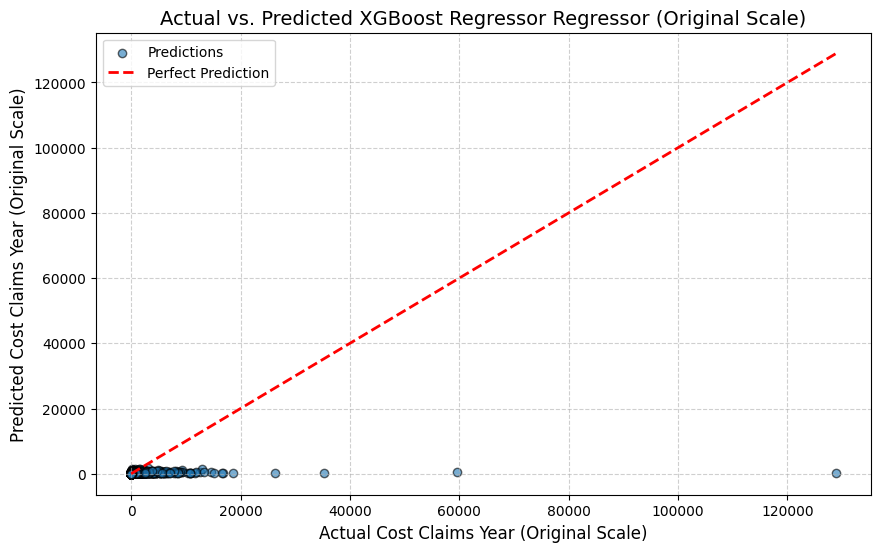

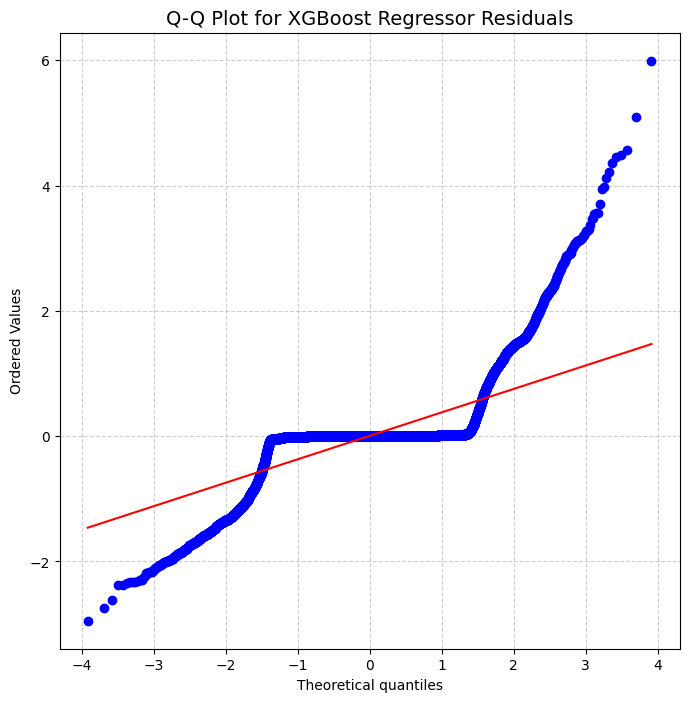

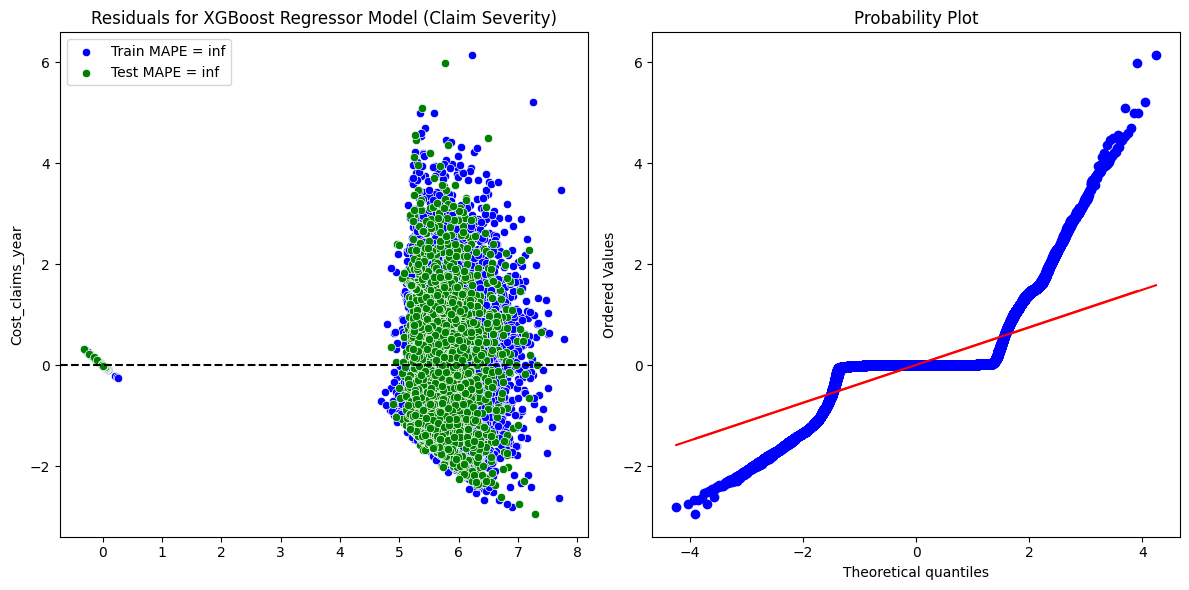

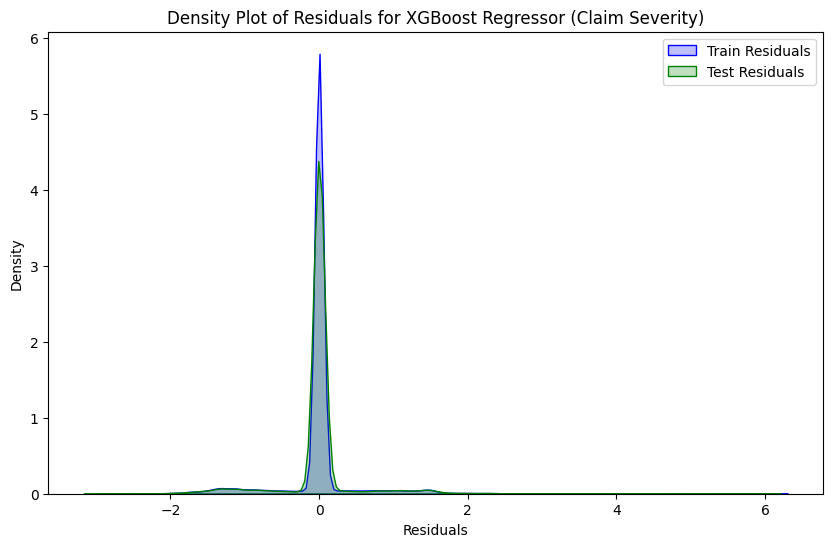

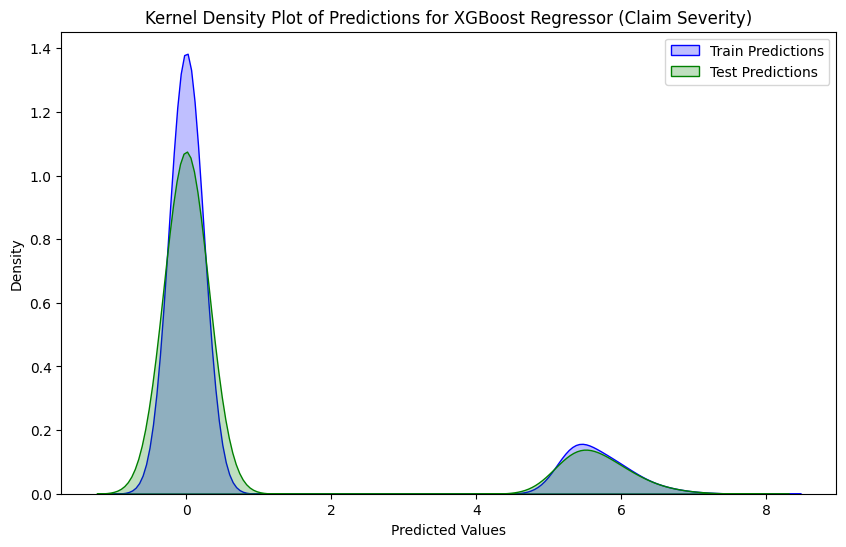

High leverage points IDs: [43548, 36425, 40779, 38920, 43064, 33079, 16599, 43559, 53416, 3611, 51770, 6256, 2064, 27843, 22883, 24252, 5336, 15436, 36655, 43362, 34961, 7685, 46965, 36840, 30380, 12725, 45991, 34926, 18598, 43723, 18444, 29941, 12554, 23459, 50561, 13258, 19931, 2061, 4670, 12596, 17027, 23253, 28977, 28098, 7464, 44823, 19967, 40886, 1853, 7722, 37458, 35689, 44203, 31617, 44111, 41143, 20777, 8670, 16436, 12167, 27955, 16444, 47755, 16677, 21533, 18105, 16554, 42949, 43187, 47384, 14364, 19051, 8204, 15617, 13373, 34759, 35850, 45237, 1400, 15147, 18343, 38005, 11486, 28545, 47510, 16884, 41283, 7772, 45684, 22434, 22342, 611, 26617, 39149, 46635, 42574, 22269, 48278, 16629, 18147, 19426, 12254, 29909, 40036, 43890, 27126, 16574, 35740, 44098, 40036, 2569, 44062, 30508, 24765, 51737, 45085, 52279, 16299, 29582, 20069, 11215, 23463, 35609, 14086, 23878, 51263, 16680, 34393, 44936, 10832, 31793, 23462, 51433, 18848, 20675, 9228, 43166, 26745, 41030, 20471, 15583, 3278

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
selected_features_xg_SHAP= [
'N_claims_year',
'R_Claims_history',
'Year_matriculation',
'Premium',
'N_claims_history',
'Value_vehicle',
'Weight',
'Cylinder_capacity',
'Seniority',
'Driving_experience_years']
# Define the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [200],
    'max_depth': [2],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [1.0]
}

best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_xg_SHAP,  # Pass the selected features
    model_name="XGBoost Regressor"
)

c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2530
  Mean Absolute Error (MAE): 0.1759


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2758
  Mean Absolute Error (MAE): 0.1849


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2632
  Mean Absolute Error (MAE): 0.1807


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2621
  Mean Absolute Error (MAE): 0.1818


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for Random Forest:
{'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_depth': 10}


Random Forest Cross-Validation Summary:
  Fold 1: MSE = 0.2530, MAE = 0.1759
  Fold 2: MSE = 0.2758, MAE = 0.1849
  Fold 3: MSE = 0.2607, MAE = 0.1794
  Fold 4: MSE = 0.2632, MAE = 0.1807
  Fold 5: MSE = 0.2621, MAE = 0.1818

Random Forest Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2165
Mean Absolute Error (MAE - Training, Log Transformed): 0.1639
R² Score (Training): 0.9559

Random Forest Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2627
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1770
R² Score (Testing): 0.9451
Mean Absolute Percentage Error (MAPE - Training, Original Scale): 1.1914
Mean Absolute Error (MAE - Training, Original Scale): 111.1677
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): 1.4031
Mean Absolute Error (MAE - Testing, Original Scale): 117.4723


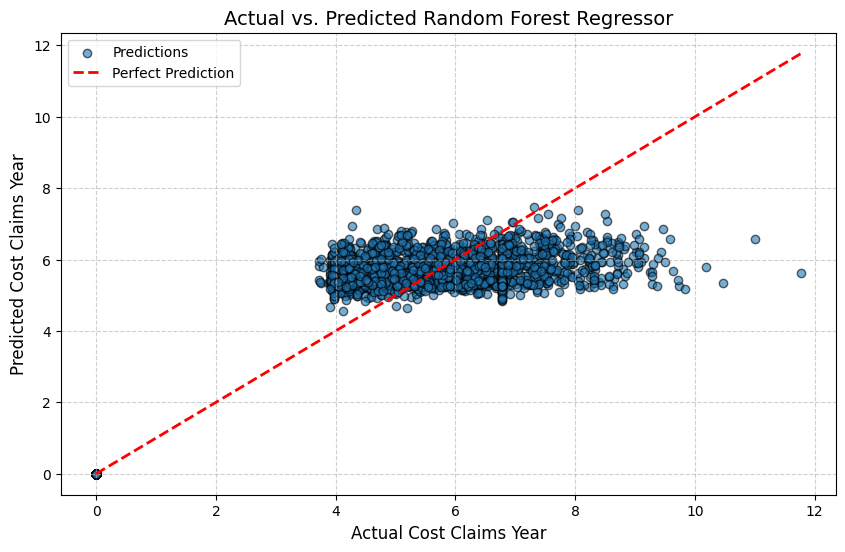

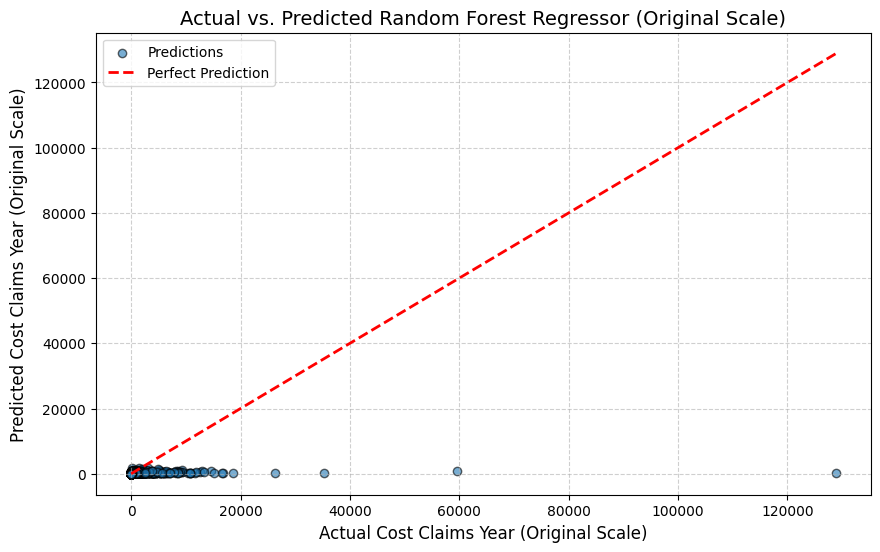

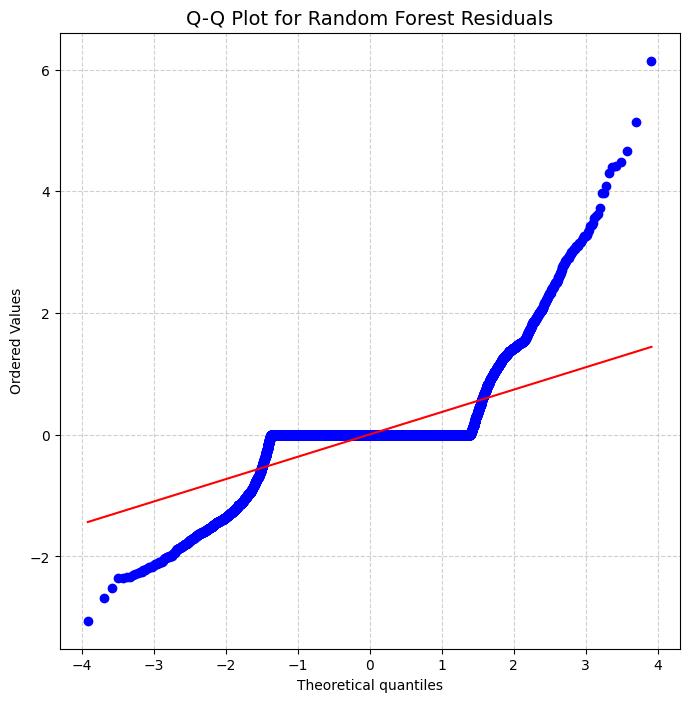

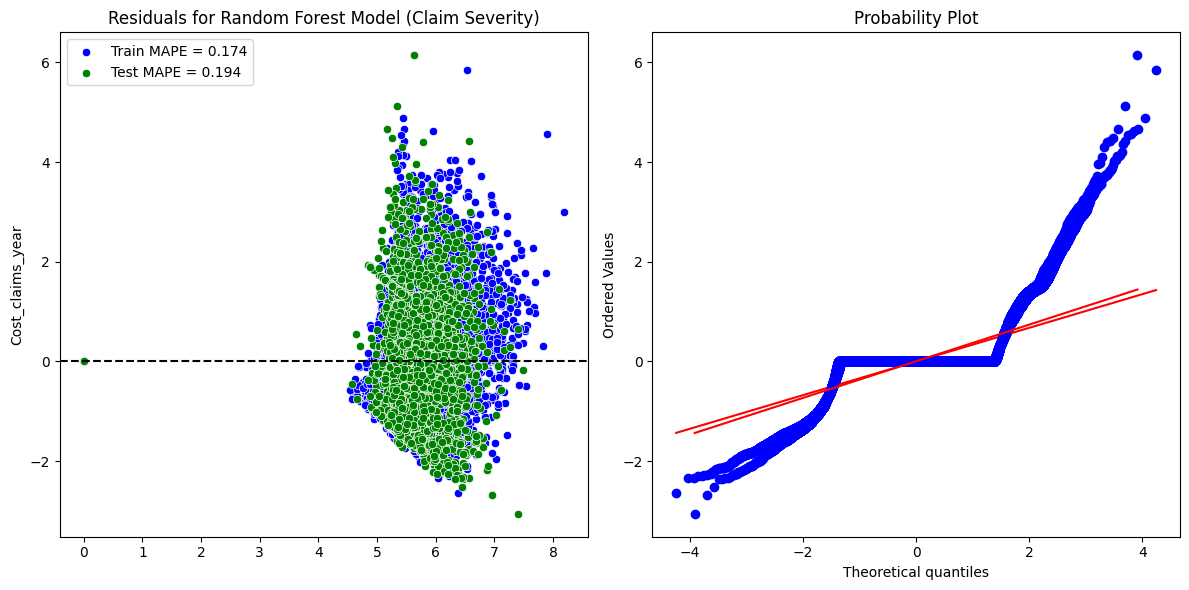

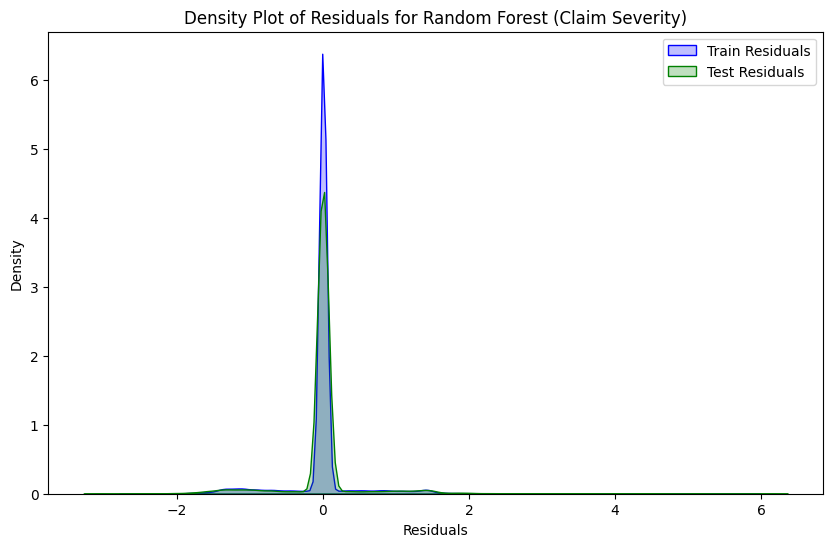

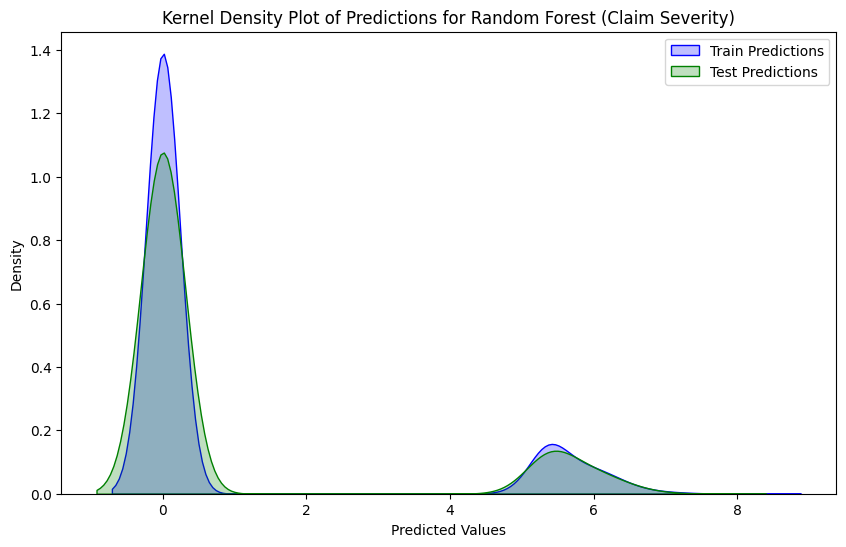

High leverage points IDs: [43548, 36425, 40779, 42452, 38920, 43064, 33079, 43559, 53416, 3611, 51770, 12519, 2064, 27843, 22883, 24252, 5336, 15436, 36655, 42603, 43362, 31254, 38750, 34961, 7685, 46965, 30380, 45991, 34926, 18598, 2015, 26274, 8964, 18444, 22818, 19309, 12554, 23459, 50561, 13258, 19931, 4670, 12596, 23253, 28977, 28098, 46612, 15031, 7464, 17348, 44823, 19967, 40886, 1853, 7722, 37458, 35689, 44203, 31617, 44111, 41143, 29405, 14592, 8670, 4029, 16436, 6539, 12167, 16444, 47755, 43576, 16677, 21533, 41762, 18105, 42949, 46630, 43187, 45172, 47384, 14364, 2236, 19051, 8204, 15617, 13373, 34759, 35850, 1400, 15147, 18343, 38005, 11486, 28545, 13188, 47510, 34889, 16884, 7772, 45684, 22434, 22342, 611, 39149, 46635, 22269, 48278, 16629, 18147, 29909, 40036, 43890, 27126, 35740, 40897, 44098, 41367, 40036, 46095, 2569, 44062, 30508, 11271, 24765, 51737, 45085, 52279, 12519, 11215, 23463, 35609, 46486, 14086, 23878, 51263, 16680, 43576, 21955, 34393, 44936, 2346, 25562, 

In [9]:
selected_features_rf_10 =[
'N_claims_year',
'Premium',
'Year_matriculation',
'R_Claims_history',
'Weight',
'Value_vehicle',
'Cylinder_capacity',
'N_claims_history',
'Driving_experience_years',
'Power']
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [250],
    'max_depth': [10],
    'min_samples_split': [5],
    'min_samples_leaf': [6]
}

best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=rf_model,
    param_grid=rf_param_grid,
    selected_features=selected_features_rf_10,  
    model_name="Random Forest"
)



c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2542
  Mean Absolute Error (MAE): 0.1795


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2738
  Mean Absolute Error (MAE): 0.1872


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2592
  Mean Absolute Error (MAE): 0.1824


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2607
  Mean Absolute Error (MAE): 0.1848


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for Gradient Boosting:
{'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.1}


Gradient Boosting Cross-Validation Summary:
  Fold 1: MSE = 0.2542, MAE = 0.1795
  Fold 2: MSE = 0.2738, MAE = 0.1872
  Fold 3: MSE = 0.2565, MAE = 0.1814
  Fold 4: MSE = 0.2592, MAE = 0.1824
  Fold 5: MSE = 0.2607, MAE = 0.1848

Gradient Boosting Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2525
Mean Absolute Error (MAE - Training, Log Transformed): 0.1795
R² Score (Training): 0.9486

Gradient Boosting Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2634
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1798
R² Score (Testing): 0.9450
Mean Absolute Percentage Error (MAPE - Training, Original Scale): inf
Mean Absolute Error (MAE - Training, Original Scale): 116.5131
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): inf
Mean Absolute Error (MAE - Testing, 

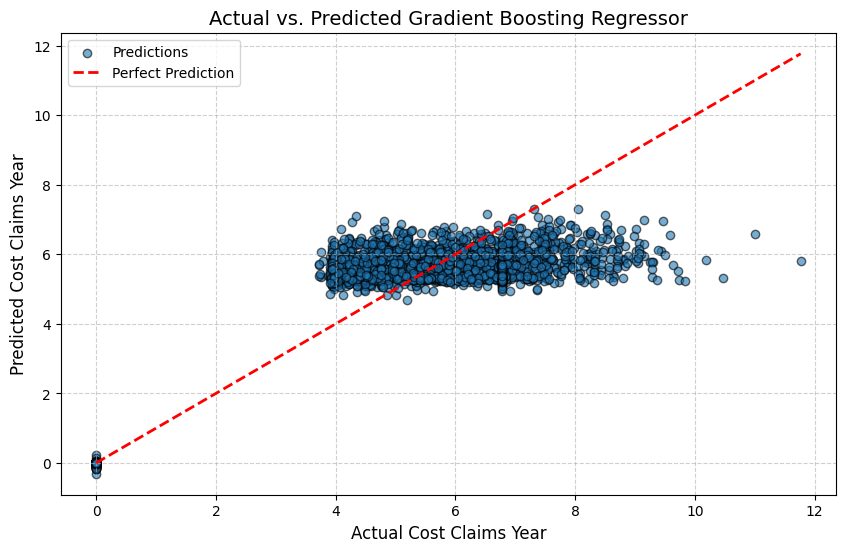

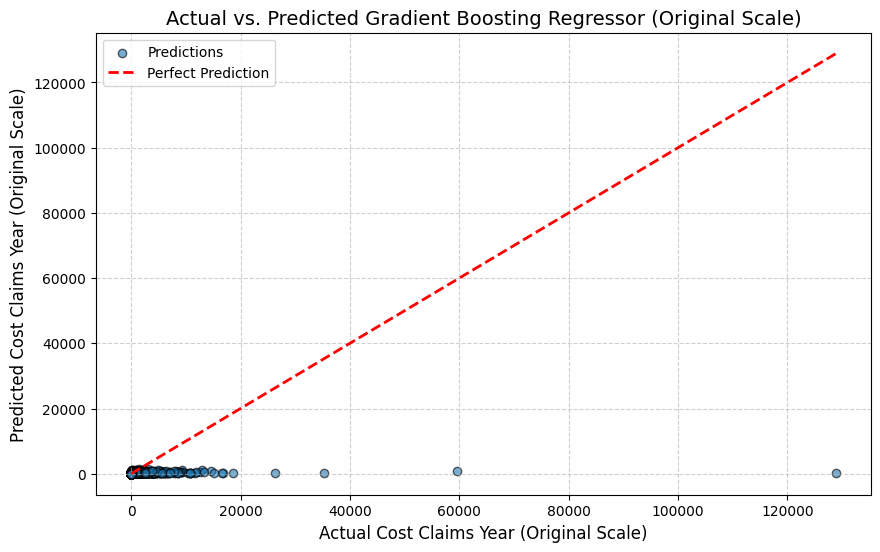

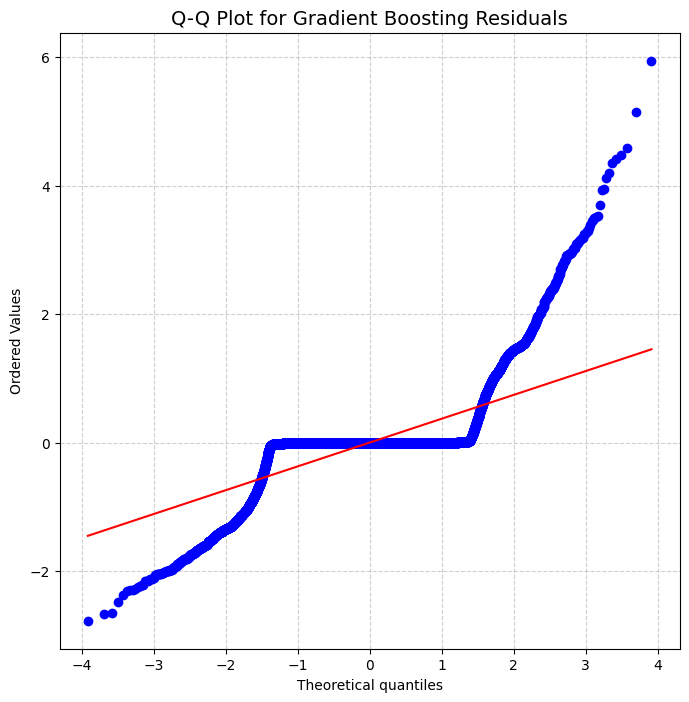

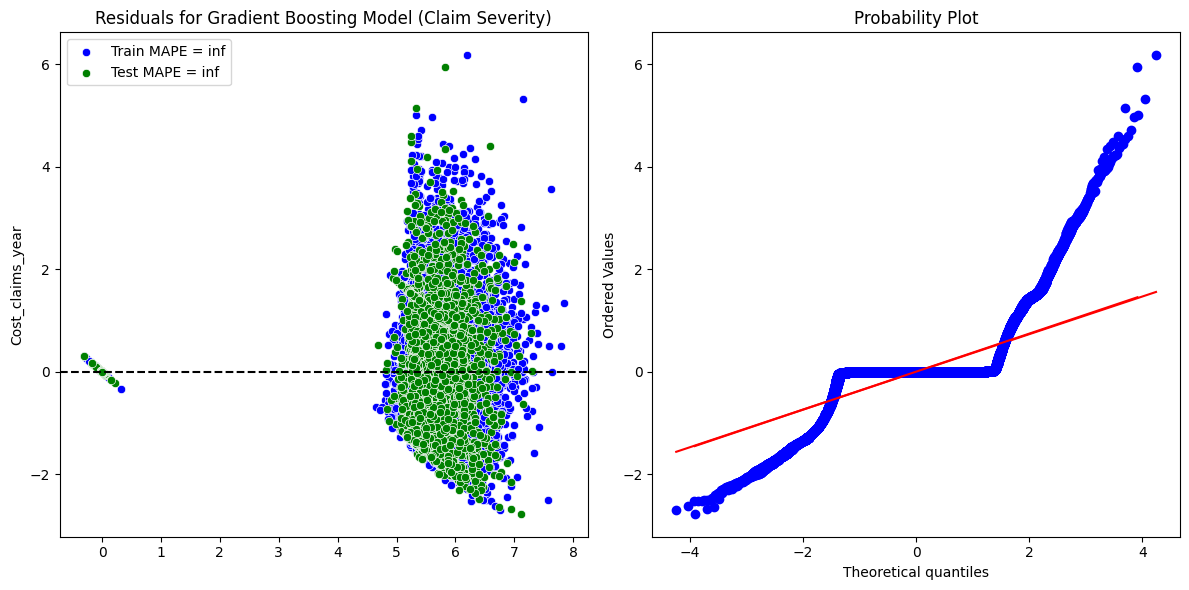

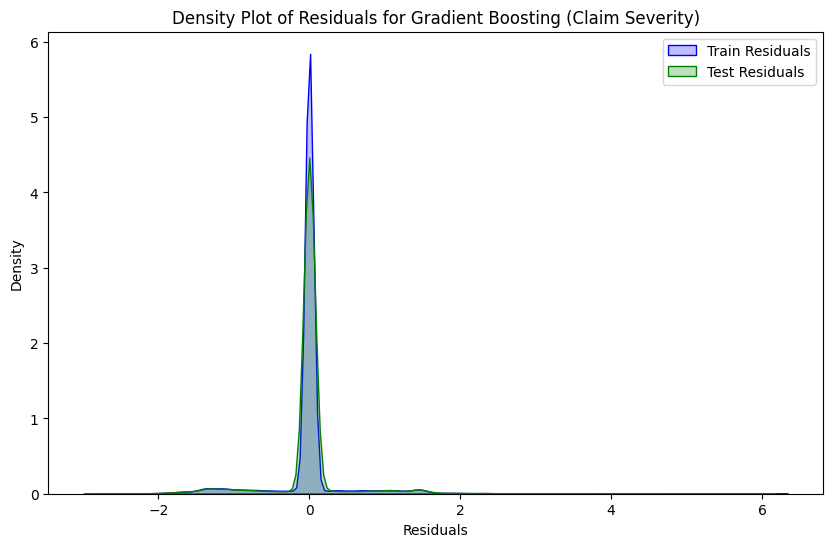

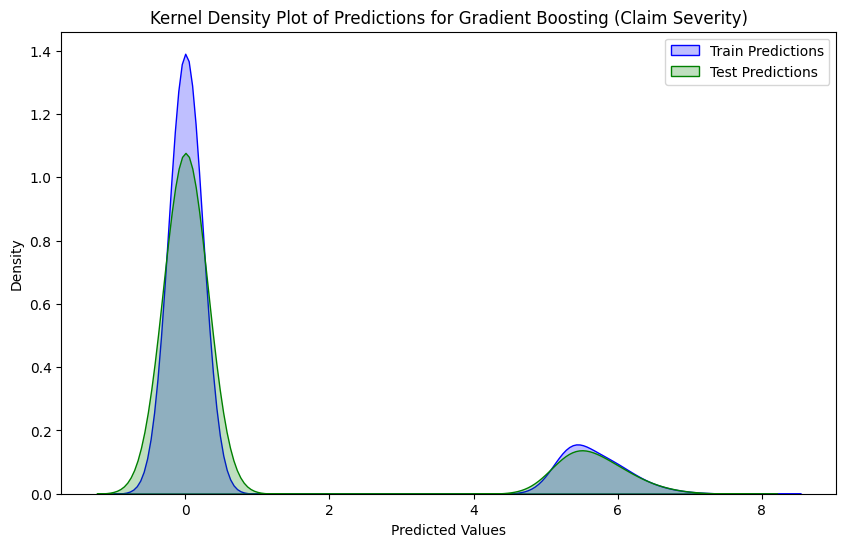

High leverage points IDs: [43548, 36425, 40779, 38920, 43064, 33079, 16599, 43559, 53416, 3611, 51770, 6256, 2064, 27843, 22883, 24252, 5336, 15436, 36655, 43362, 34961, 7685, 46965, 36840, 30380, 12725, 45991, 34926, 18598, 43723, 18444, 29941, 12554, 23459, 50561, 13258, 19931, 2061, 4670, 12596, 17027, 23253, 28977, 28098, 7464, 44823, 19967, 40886, 1853, 7722, 37458, 35689, 44203, 31617, 44111, 41143, 20777, 8670, 16436, 12167, 27955, 16444, 47755, 16677, 21533, 18105, 16554, 42949, 43187, 47384, 14364, 19051, 8204, 15617, 13373, 34759, 35850, 45237, 1400, 15147, 18343, 38005, 11486, 28545, 47510, 16884, 41283, 7772, 45684, 22434, 22342, 611, 26617, 39149, 46635, 42574, 22269, 48278, 16629, 18147, 19426, 12254, 29909, 40036, 43890, 27126, 16574, 35740, 44098, 40036, 2569, 44062, 30508, 24765, 51737, 45085, 52279, 16299, 29582, 20069, 11215, 23463, 35609, 14086, 23878, 51263, 16680, 34393, 44936, 10832, 31793, 23462, 51433, 18848, 20675, 9228, 43166, 26745, 41030, 20471, 15583, 3278

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
selected_features_gb_shap = [
'N_claims_year',
'Year_matriculation',
'R_Claims_history',
'Premium',
'N_claims_history',
'Weight',
'Value_vehicle',
'Cylinder_capacity',
'Seniority',
'Driving_experience_years'
]
# Define Gradient Boosting Model and its hyperparameter grid
gbm_model = GradientBoostingRegressor(random_state=42)
gbm_param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [8],
    'min_samples_leaf': [1, 2, 4]
}

best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=gbm_model,
    param_grid=gbm_param_grid,
    selected_features=selected_features_gb_shap,  
    model_name="Gradient Boosting"
)


### Boruta

c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2586
  Mean Absolute Error (MAE): 0.1837


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2775
  Mean Absolute Error (MAE): 0.1906


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2665
  Mean Absolute Error (MAE): 0.1872


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2660
  Mean Absolute Error (MAE): 0.1899


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for XGBoost Regressor (Bu):
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


XGBoost Regressor (Bu) Cross-Validation Summary:
  Fold 1: MSE = 0.2586, MAE = 0.1837
  Fold 2: MSE = 0.2775, MAE = 0.1906
  Fold 3: MSE = 0.2644, MAE = 0.1864
  Fold 4: MSE = 0.2665, MAE = 0.1872
  Fold 5: MSE = 0.2660, MAE = 0.1899

XGBoost Regressor (Bu) Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2313
Mean Absolute Error (MAE - Training, Log Transformed): 0.1737
R² Score (Training): 0.9529

XGBoost Regressor (Bu) Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2658
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1831
R² Score (Testing): 0.9445
Mean Absolute Percentage Error (MAPE - Training, Original Scale): inf
Mean Absolute Error (MAE - Training, Original Scale): 112.6989
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): inf
Mean Absolute Error 

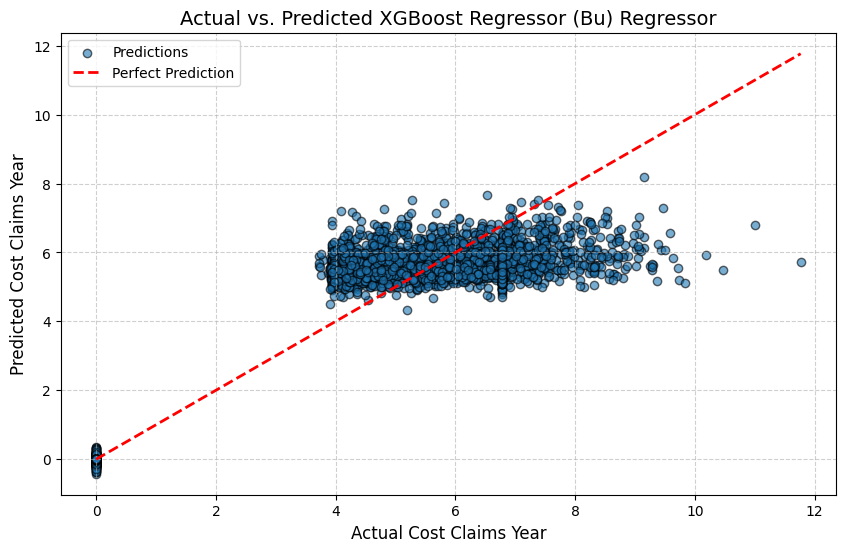

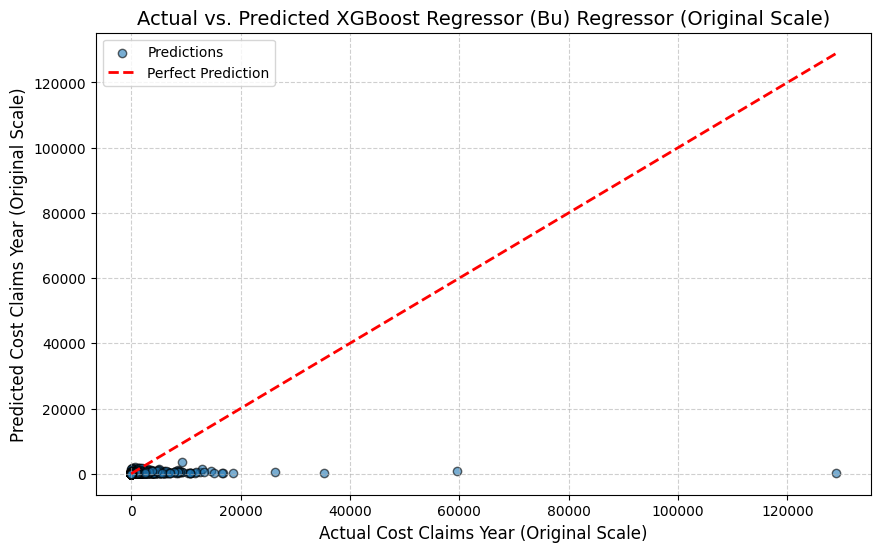

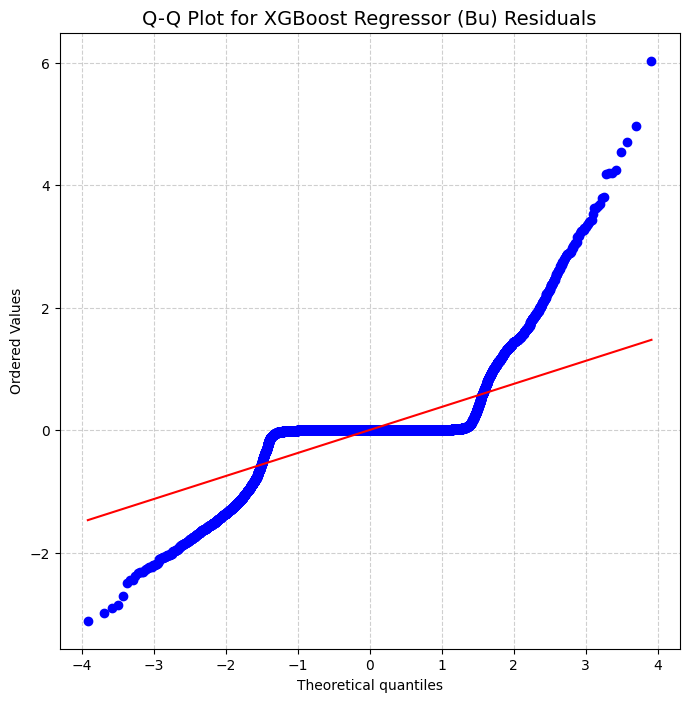

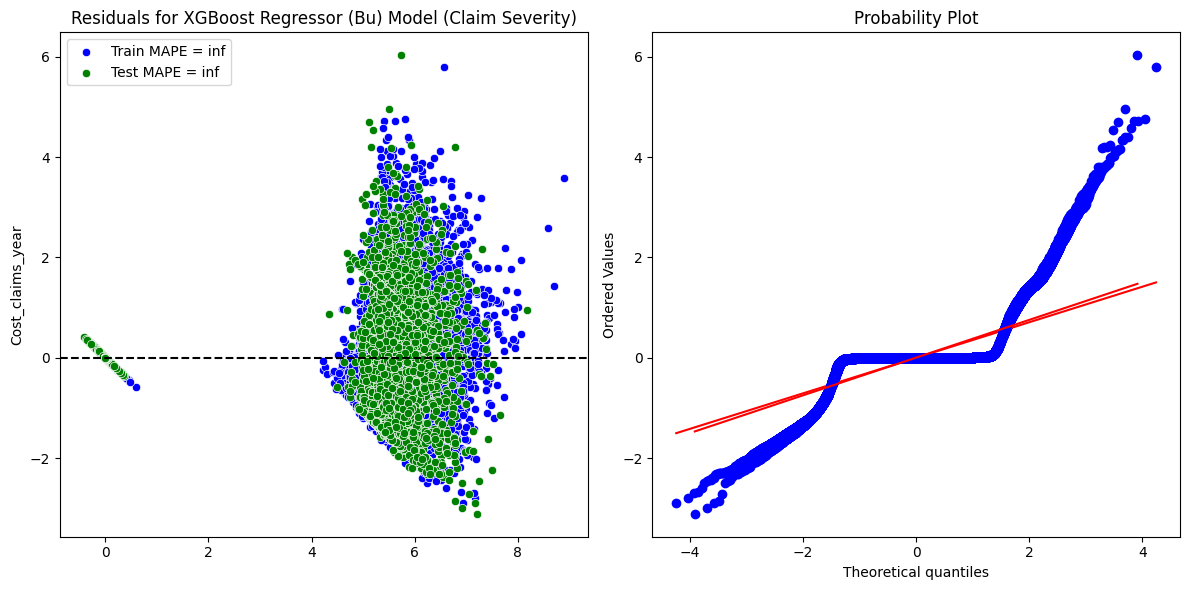

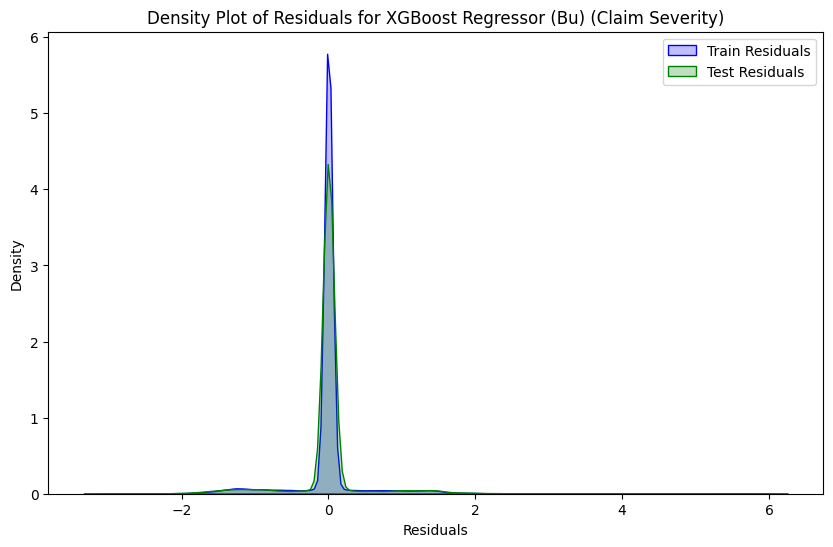

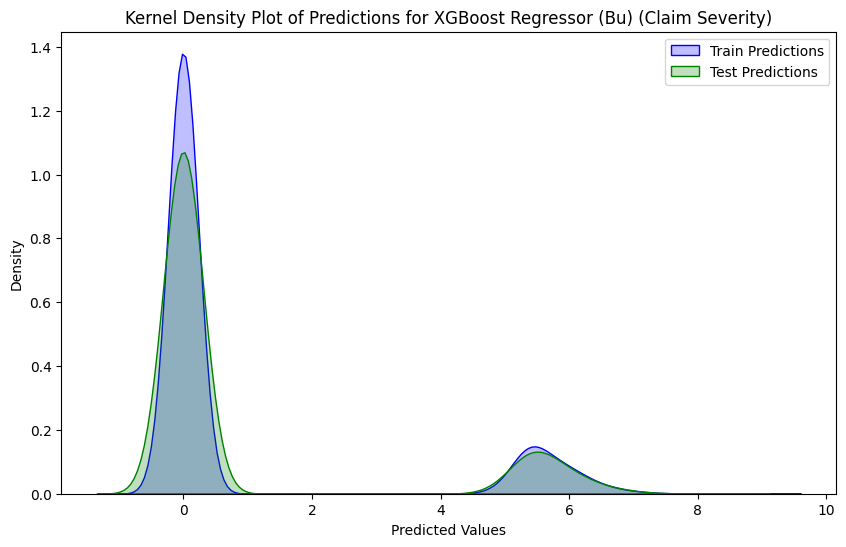

High leverage points IDs: [43548, 36425, 40779, 38920, 43064, 33079, 16599, 43559, 53416, 3611, 51770, 6256, 2064, 27843, 22883, 24252, 5336, 15436, 36655, 43362, 34961, 7685, 46965, 36840, 30380, 12725, 45991, 34926, 18598, 43723, 18444, 29941, 12554, 23459, 50561, 13258, 19931, 2061, 4670, 12596, 17027, 23253, 28977, 28098, 7464, 44823, 19967, 40886, 1853, 7722, 37458, 35689, 44203, 31617, 44111, 41143, 20777, 8670, 16436, 12167, 27955, 16444, 47755, 16677, 21533, 18105, 16554, 42949, 43187, 47384, 14364, 19051, 8204, 15617, 13373, 34759, 35850, 45237, 1400, 15147, 18343, 38005, 11486, 28545, 47510, 16884, 41283, 7772, 45684, 22434, 22342, 611, 26617, 39149, 46635, 42574, 22269, 48278, 16629, 18147, 19426, 12254, 29909, 40036, 43890, 27126, 16574, 35740, 44098, 40036, 2569, 44062, 30508, 24765, 51737, 45085, 52279, 16299, 29582, 20069, 11215, 23463, 35609, 14086, 23878, 51263, 16680, 34393, 44936, 10832, 31793, 23462, 51433, 18848, 20675, 9228, 43166, 26745, 41030, 20471, 15583, 3278

In [15]:

selected_features_xg_Bu = [
'Year_matriculation',
'Premium',
'N_claims_year',
'R_Claims_history',
'Weight',
'Payment',
'Area',
'Power',
'Value_vehicle',
'Second_driver']
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100],
    'max_depth': [4],
    'learning_rate': [0.2],
    'subsample': [0.7],
    'colsample_bytree': [1.0]
}

best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_xg_SHAP,  # Pass the selected features
    model_name="XGBoost Regressor (Bu)"
)

c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2532
  Mean Absolute Error (MAE): 0.1759


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2757
  Mean Absolute Error (MAE): 0.1849


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2637
  Mean Absolute Error (MAE): 0.1809


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2621
  Mean Absolute Error (MAE): 0.1818


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for Random Forest (Bu):
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}


Random Forest (Bu) Cross-Validation Summary:
  Fold 1: MSE = 0.2532, MAE = 0.1759
  Fold 2: MSE = 0.2757, MAE = 0.1849
  Fold 3: MSE = 0.2606, MAE = 0.1794
  Fold 4: MSE = 0.2637, MAE = 0.1809
  Fold 5: MSE = 0.2621, MAE = 0.1818

Random Forest (Bu) Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2133
Mean Absolute Error (MAE - Training, Log Transformed): 0.1627
R² Score (Training): 0.9566

Random Forest (Bu) Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2630
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1771
R² Score (Testing): 0.9451
Mean Absolute Percentage Error (MAPE - Training, Original Scale): 1.1780
Mean Absolute Error (MAE - Training, Original Scale): 110.5859
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): 1.4049
Mean Absolute Error (MAE - Testing, Original Sc

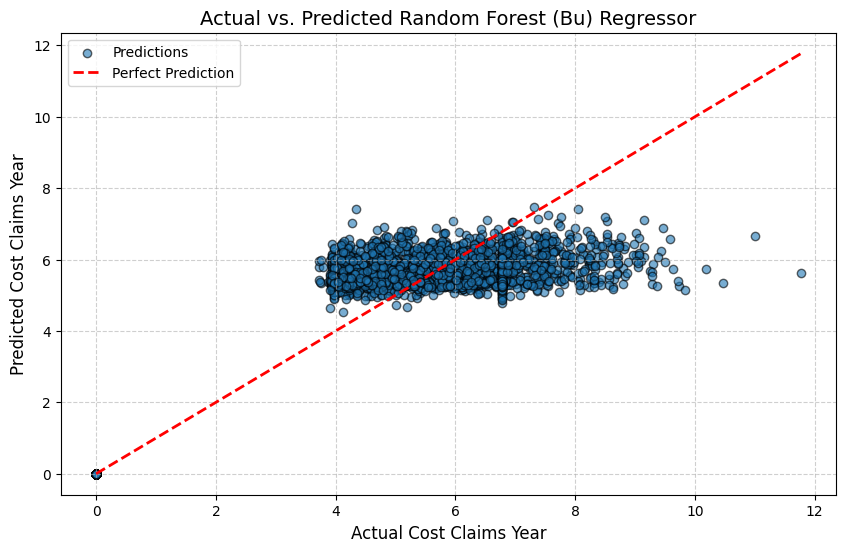

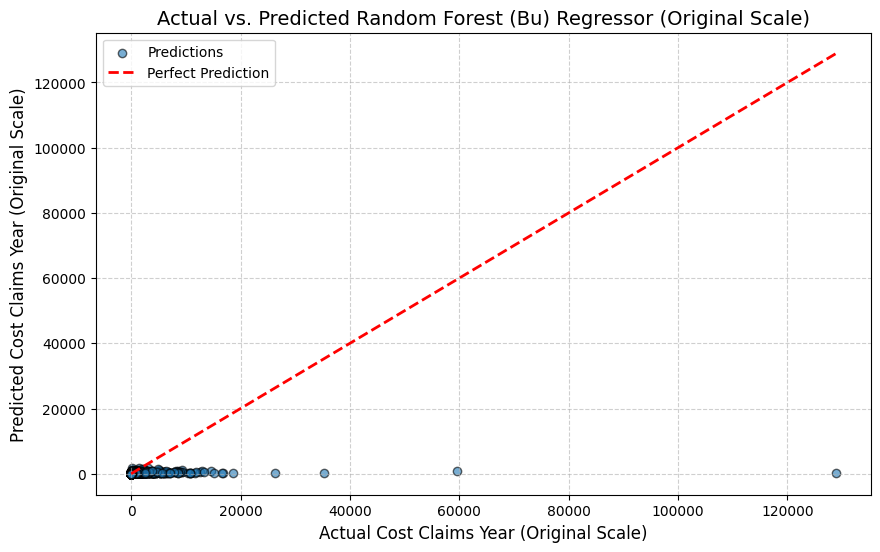

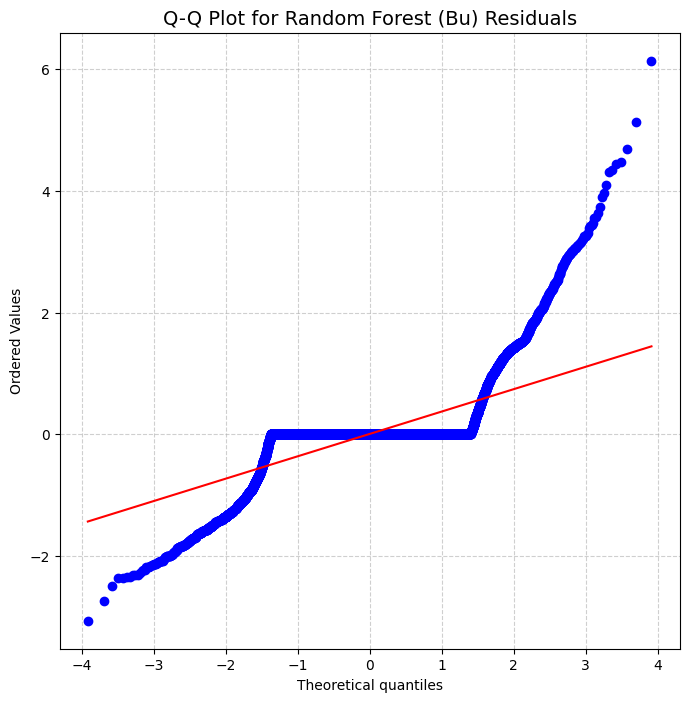

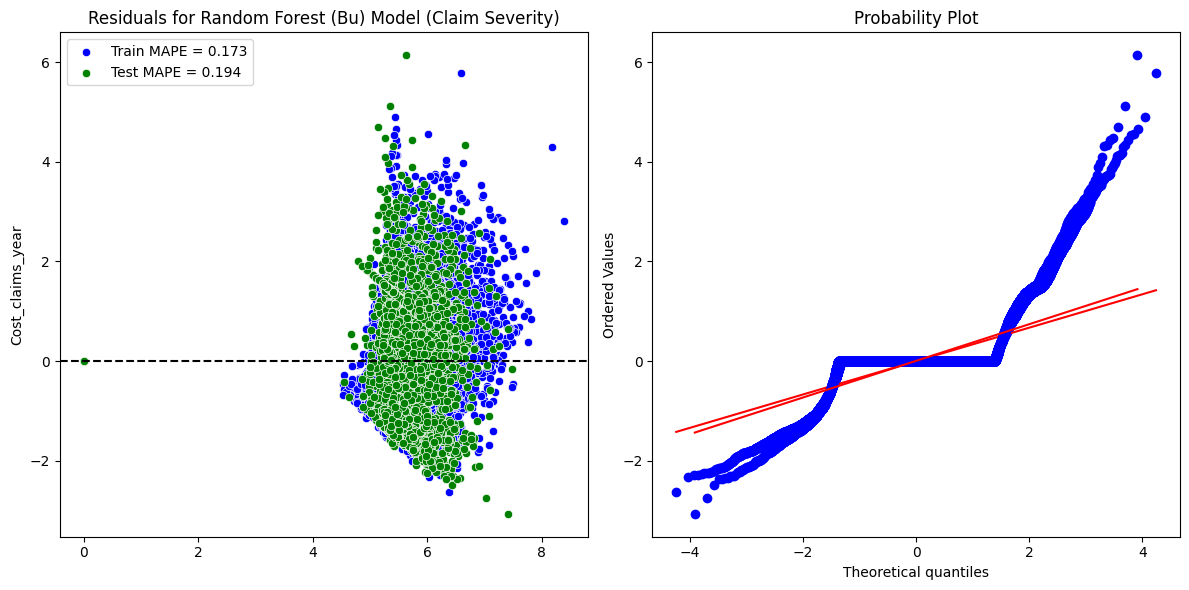

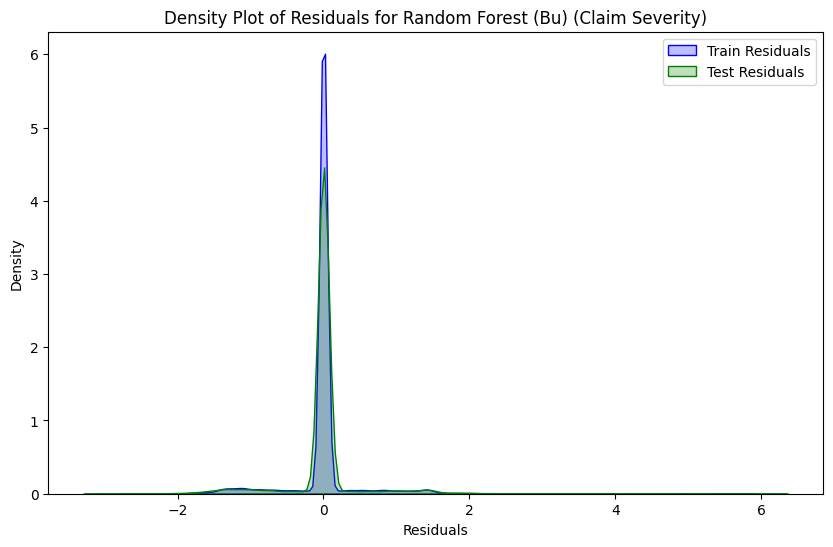

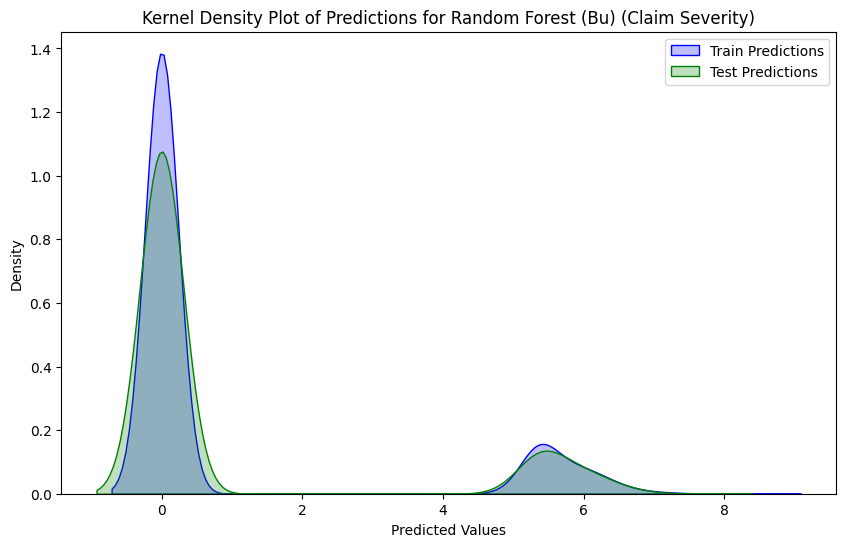

High leverage points IDs: [43548, 36425, 40779, 42452, 38920, 43064, 33079, 43559, 53416, 3611, 51770, 12519, 2064, 27843, 22883, 24252, 5336, 15436, 36655, 42603, 43362, 31254, 38750, 34961, 7685, 46965, 30380, 45991, 34926, 18598, 2015, 26274, 8964, 18444, 22818, 19309, 12554, 23459, 50561, 13258, 19931, 4670, 12596, 23253, 28977, 28098, 46612, 15031, 7464, 17348, 44823, 19967, 40886, 1853, 7722, 37458, 35689, 44203, 31617, 44111, 41143, 29405, 14592, 8670, 4029, 16436, 6539, 12167, 16444, 47755, 43576, 16677, 21533, 41762, 18105, 42949, 46630, 43187, 45172, 47384, 14364, 2236, 19051, 8204, 15617, 13373, 34759, 35850, 1400, 15147, 18343, 38005, 11486, 28545, 13188, 47510, 34889, 16884, 7772, 45684, 22434, 22342, 611, 39149, 46635, 22269, 48278, 16629, 18147, 29909, 40036, 43890, 27126, 35740, 40897, 44098, 41367, 40036, 46095, 2569, 44062, 30508, 11271, 24765, 51737, 45085, 52279, 12519, 11215, 23463, 35609, 46486, 14086, 23878, 51263, 16680, 43576, 21955, 34393, 44936, 2346, 25562, 

In [17]:
selected_features_rf_bu = [
'Year_matriculation',
'Premium',
'N_claims_year',
'R_Claims_history',
'Value_vehicle',
'Weight',
'Driving_experience_years',
'Cylinder_capacity',
'Power',
'N_claims_history']

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [200],
    'max_depth': [10],
    'min_samples_split': [5],
    'min_samples_leaf': [4]
}

best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=rf_model,
    param_grid=rf_param_grid,
    selected_features=selected_features_rf_10,  
    model_name="Random Forest (Bu)"
)

c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2544
  Mean Absolute Error (MAE): 0.1839


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2737
  Mean Absolute Error (MAE): 0.1917


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2600
  Mean Absolute Error (MAE): 0.1871


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2610
  Mean Absolute Error (MAE): 0.1897


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for Gradient Boosting (Bu):
{'n_estimators': 250, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.1}


Gradient Boosting (Bu) Cross-Validation Summary:
  Fold 1: MSE = 0.2544, MAE = 0.1839
  Fold 2: MSE = 0.2737, MAE = 0.1917
  Fold 3: MSE = 0.2560, MAE = 0.1848
  Fold 4: MSE = 0.2600, MAE = 0.1871
  Fold 5: MSE = 0.2610, MAE = 0.1897

Gradient Boosting (Bu) Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2548
Mean Absolute Error (MAE - Training, Log Transformed): 0.1845
R² Score (Training): 0.9482

Gradient Boosting (Bu) Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2635
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1840
R² Score (Testing): 0.9450
Mean Absolute Percentage Error (MAPE - Training, Original Scale): inf
Mean Absolute Error (MAE - Training, Original Scale): 116.8542
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): inf
Mean Absolute Er

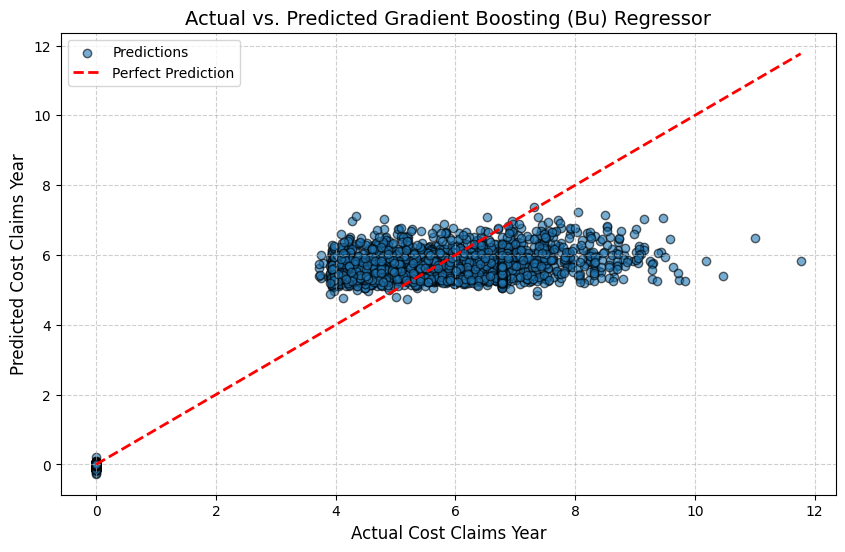

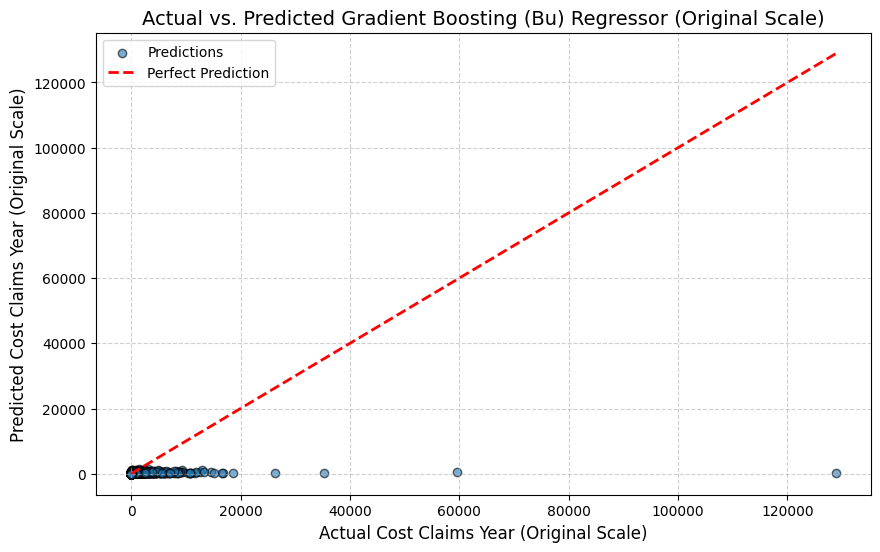

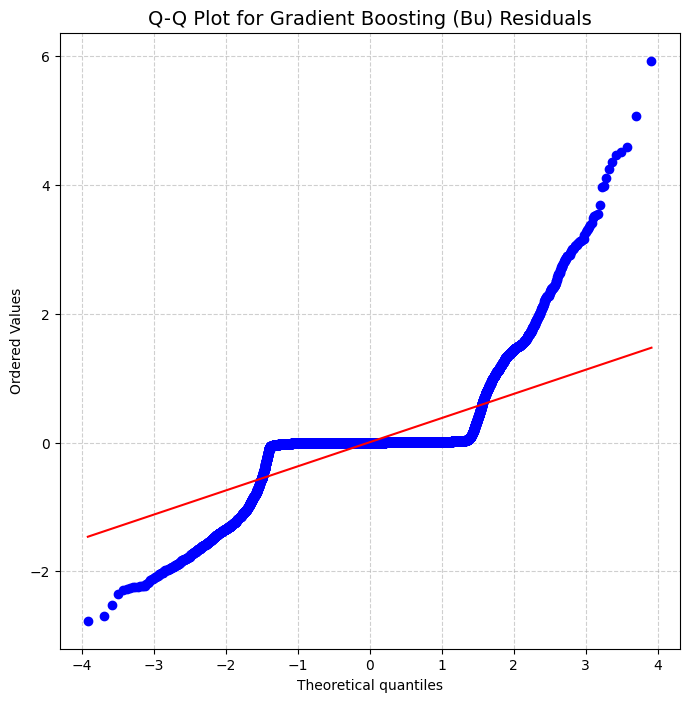

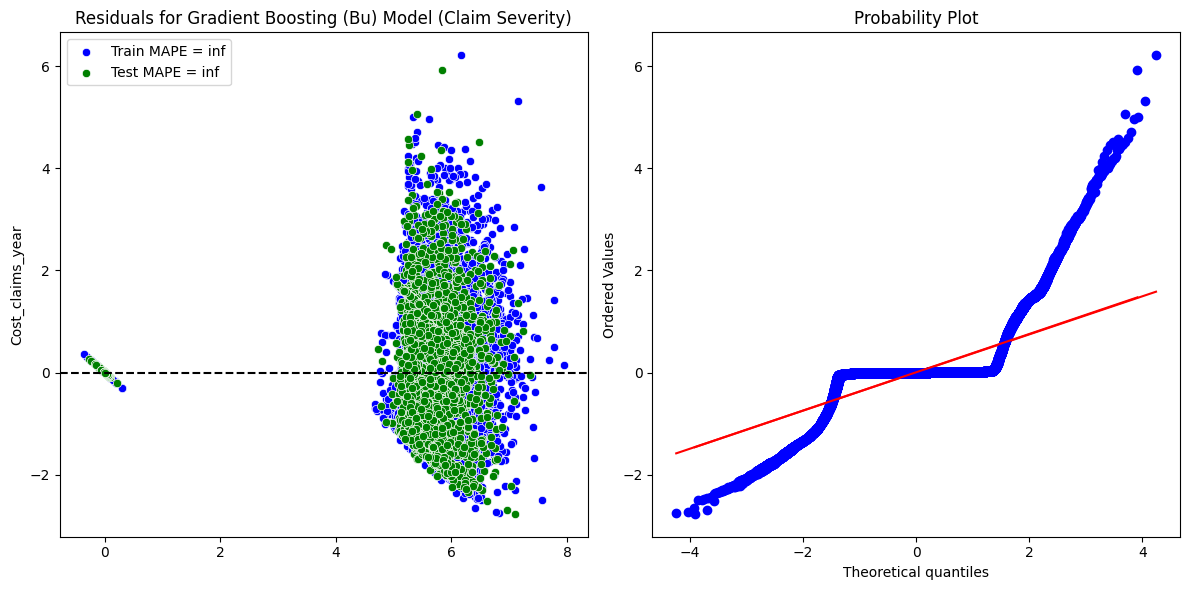

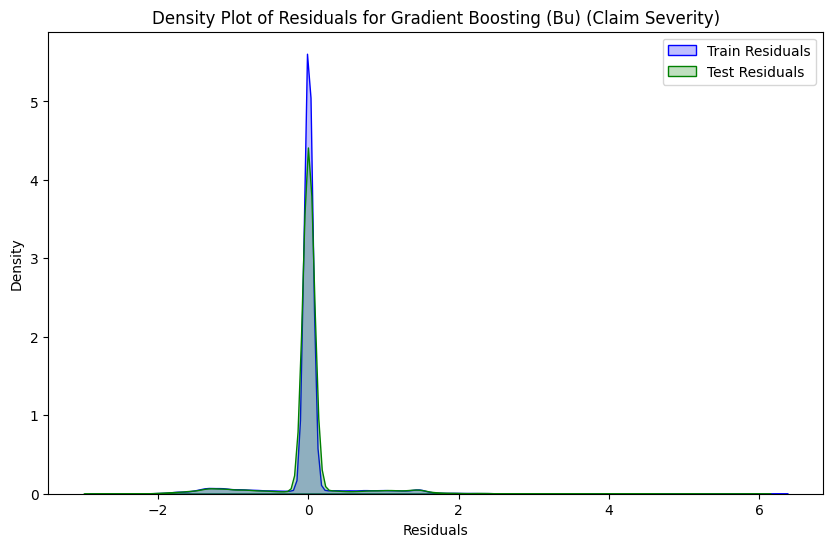

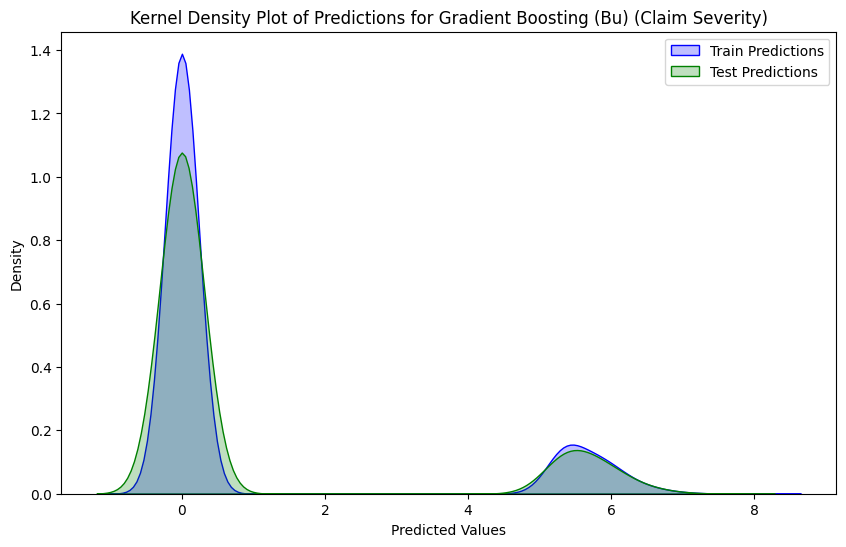

High leverage points IDs: [43548, 36425, 40779, 38920, 43064, 33079, 16599, 43559, 53416, 3611, 51770, 6256, 2064, 27843, 22883, 24252, 5336, 15436, 36655, 43362, 34961, 7685, 46965, 36840, 30380, 12725, 45991, 34926, 18598, 43723, 18444, 29941, 12554, 23459, 50561, 13258, 19931, 2061, 4670, 12596, 17027, 23253, 28977, 28098, 7464, 44823, 19967, 40886, 1853, 7722, 37458, 35689, 44203, 31617, 44111, 41143, 20777, 8670, 16436, 12167, 27955, 16444, 47755, 16677, 21533, 18105, 16554, 42949, 43187, 47384, 14364, 19051, 8204, 15617, 13373, 34759, 35850, 45237, 1400, 15147, 18343, 38005, 11486, 28545, 47510, 16884, 41283, 7772, 45684, 22434, 22342, 611, 26617, 39149, 46635, 42574, 22269, 48278, 16629, 18147, 19426, 12254, 29909, 40036, 43890, 27126, 16574, 35740, 44098, 40036, 2569, 44062, 30508, 24765, 51737, 45085, 52279, 16299, 29582, 20069, 11215, 23463, 35609, 14086, 23878, 51263, 16680, 34393, 44936, 10832, 31793, 23462, 51433, 18848, 20675, 9228, 43166, 26745, 41030, 20471, 15583, 3278

In [19]:

selected_features_gb_Bu = [
'Year_matriculation',
'Value_vehicle',
'R_Claims_history',
'N_claims_history',
'N_claims_year',
'Weight',
'Premium',
'Cylinder_capacity',
'Power',
'Seniority']

gbm_model = GradientBoostingRegressor(random_state=42)
gbm_param_grid = {
    'n_estimators': [250],
    'learning_rate': [0.1],
    'max_depth': [2],
    'min_samples_split': [8],
    'min_samples_leaf': [1, 2, 4]
}

best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=gbm_model,
    param_grid=gbm_param_grid,
    selected_features=selected_features_gb_shap,  
    model_name="Gradient Boosting (Bu)"
)

### Full

In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 

df_train = pd.read_csv('train_cleaned.csv')
df_test =  pd.read_csv('test_cleaned.csv')
# Function to calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def run_model_with_top_features_and_qq_plot(df_train, df_test, model, param_grid, model_name="Model"):

    # Separate features and target variable in training and test datasets
    X_train = df_train.drop(columns=['Cost_claims_year', "ID"])  # Replace 'Cost_claims_year' if different
    y_train = df_train['Cost_claims_year']
    X_test = df_test.drop(columns=['Cost_claims_year', "ID"])
    y_test = df_test['Cost_claims_year']

    # Nested cross-validation with hyperparameter tuning
    def hyperparameter_tuning_with_nested_cv(model, param_grid, X_train, y_train):
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

        fold_metrics = []  # To store metrics for each fold

        for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
            X_fold_train, X_fold_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
            y_fold_train, y_fold_valid = y_train.iloc[train_idx], y_train.iloc[valid_idx]

            # Run hyperparameter tuning on the training fold
            grid_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                cv=inner_cv,
                n_jobs=-1,
                scoring='neg_mean_squared_error',
                random_state=42
            )
            grid_search.fit(X_fold_train, y_fold_train)

            # Use the best model to predict the validation fold
            best_model = grid_search.best_estimator_
            y_pred_valid = best_model.predict(X_fold_valid)

            # Calculate metrics for the validation fold
            mse_fold = mean_squared_error(y_fold_valid, y_pred_valid)
            mae_fold = mean_absolute_error(y_fold_valid, y_pred_valid)

            # Print metrics for the fold
            print(f"Fold {fold} Results:")
            print(f"  Mean Squared Error (MSE): {mse_fold:.4f}")
            print(f"  Mean Absolute Error (MAE): {mae_fold:.4f}")

            # Store metrics for summary
            fold_metrics.append((fold, mse_fold, mae_fold))

        # After cross-validation, refit on the entire training set and return the best model
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

        return best_model, best_params, fold_metrics

    # Run nested CV and get the best model and fold metrics
    best_model, best_params, fold_metrics = hyperparameter_tuning_with_nested_cv(
        model, param_grid, X_train, y_train
    )

    print(f"\nBest Parameters from Grid Search for {model_name}:\n{best_params}\n")

    # Summary of metrics across folds
    print(f"\n{model_name} Cross-Validation Summary:")
    for fold, mse_fold, mae_fold in fold_metrics:
        print(f"  Fold {fold}: MSE = {mse_fold:.4f}, MAE = {mae_fold:.4f}")

    # Evaluate the model on the full test set
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Calculate metrics for training and testing
    mse_train = mean_squared_error(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Print evaluation results
    print(f"\n{model_name} Model Evaluation on Training Set:")
    print(f"Mean Squared Error (MSE - Training): {mse_train:.4f}")
    print(f"Mean Absolute Error (MAE - Training, Log Transformed): {mae_train:.4f}")
    print(f"R² Score (Training): {r2_train:.4f}")

    print(f"\n{model_name} Model Evaluation on Test Set:")
    print(f"Mean Squared Error (MSE - Testing): {mse_test:.4f}")
    print(f"Mean Absolute Error (MAE - Testing, Log Transformed): {mae_test:.4f}")
    print(f"R² Score (Testing): {r2_test:.4f}")

     # Convert log-transformed predictions and true values back to their original scale
    df_train['y_true'] = y_train.copy()  # Ensure it's a copy of y_test
    df_train['y_pred'] = y_pred_train
    df_train['y_pred_nolog'] = np.expm1(y_pred_train)  # Predicted values in original scale
    df_train['y_true_nolog'] = np.expm1(y_train) 
    mae_train_exp = mean_absolute_error(df_train['y_true_nolog'], df_train['y_pred_nolog'])
    mape_train_exp = mean_absolute_percentage_error(df_train['y_true_nolog'], df_train['y_pred_nolog'])
    print(f"Mean Absolute Percentage Error (MAPE - Training, Original Scale): {mape_train_exp:.4f}")
    print(f"Mean Absolute Error (MAE - Training, Original Scale): {mae_train_exp:.4f}")

    # Convert log-transformed predictions and true values back to their original scale
    df_test['y_true'] = y_test.copy()  # Ensure it's a copy of y_test
    df_test['y_pred'] = y_pred_test
    df_test['y_pred_nolog'] = np.expm1(y_pred_test)  # Predicted values in original scale
    df_test['y_true_nolog'] = np.expm1(y_test)     
    mae_test_exp = mean_absolute_error(df_test['y_true_nolog'], df_test['y_pred_nolog'])
    mape_test_exp = mean_absolute_percentage_error(df_test['y_true_nolog'], df_test['y_pred_nolog'])
    print(f"Mean Absolute Percentage Error (MAPE - Testing, Original Scale): {mape_test_exp:.4f}")
    print(f"Mean Absolute Error (MAE - Testing, Original Scale): {mae_test_exp:.4f}")

    # Store results in new DataFrames
    train_results = df_train.copy()
    test_results = df_test.copy()

    # Add predictions and residuals to DataFrames
    train_results['y_true'] = y_train
    train_results['y_pred'] = y_pred_train
    train_results['residuals'] = y_train - y_pred_train

    test_results['y_true'] = y_test
    test_results['y_pred'] = y_pred_test
    test_results['residuals'] = y_test - y_pred_test

    # Save results
    train_results.to_csv(f"{model_name.lower().replace(' ', '_')}_train_nocut_2_increase_tune.1K.csv", index=False)
    test_results.to_csv(f"{model_name.lower().replace(' ', '_')}_test_nocut_2_increase_tune1K.csv", index=False)


    # Plot Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor", fontsize=14)
    plt.xlabel("Actual Cost Claims Year", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

     # Plot Actual vs Predicted using original scale
    plt.figure(figsize=(10, 6))
    plt.scatter(np.exp(y_test), np.exp(y_pred_test), alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([np.exp(y_test).min(), np.exp(y_test).max()], 
             [np.exp(y_test).min(), np.exp(y_test).max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor (Original Scale)", fontsize=14)
    plt.xlabel("Actual Cost Claims Year (Original Scale)", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year (Original Scale)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    # Plot Q-Q Plot for Residuals
    plt.figure(figsize=(8, 8))
    stats.probplot(residuals_test, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {model_name} Residuals", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    # Plot residuals and prediction density
    plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_prediction_kde(y_pred_train, y_pred_test, model_name)
    compute_cooks_and_leverage(X_test, y_test, y_pred_test, model_name, df_test)

    return best_model
# Density plot of residuals
def plot_residual_density(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    train_residuals, test_residuals = y_train_true - y_train_pred, y_test_true - y_test_pred
    plt.figure(figsize=(10, 6))
    sns.kdeplot(train_residuals, color='blue', fill=True, label='Train Residuals')
    sns.kdeplot(test_residuals, color='green', fill=True, label='Test Residuals')
    plt.title(f'Density Plot of Residuals for {model_name} (Claim Severity)')
    plt.xlabel('Residuals')
    plt.legend()
    plt.show()

# Density plot of predictions
def plot_prediction_kde(y_train_pred, y_test_pred, model_name):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_train_pred, color='blue', fill=True, label='Train Predictions')
    sns.kdeplot(y_test_pred, color='green', fill=True, label='Test Predictions')
    plt.title(f'Kernel Density Plot of Predictions for {model_name} (Claim Severity)')
    plt.xlabel('Predicted Values')
    plt.legend()
    plt.show()

# Function to compute Cook's distance and leverage
def compute_cooks_and_leverage(X, y_true, y_pred, model_name, df):
    residuals = y_true - y_pred
    X_with_const = sm.add_constant(X)
    linear_model = sm.OLS(residuals, X_with_const).fit()
    influence = OLSInfluence(linear_model)
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]
    leverage_threshold = 3 * np.mean(leverage)
    cooks_threshold = 4 / len(cooks_d)
    high_leverage_points = np.where(leverage > leverage_threshold)[0]
    high_cooks_points = np.where(cooks_d > cooks_threshold)[0]
    ids_high_leverage = df.loc[high_leverage_points, 'ID'].tolist()
    ids_high_cooks = df.loc[high_cooks_points, 'ID'].tolist()
    print(f"High leverage points IDs: {ids_high_leverage}")
    print(f"High Cook's distance points IDs: {ids_high_cooks}")
    return cooks_d, leverage, ids_high_leverage, ids_high_cooks

def plot_residuals_and_qq(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    train_residuals, test_residuals = y_train_true - y_train_pred, y_test_true - y_test_pred
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    sns.scatterplot(x=y_train_pred, y=train_residuals, color='blue', ax=ax1, label=f'Train MAPE = {mean_absolute_percentage_error(y_train_true, y_train_pred):.3f}')
    sns.scatterplot(x=y_test_pred, y=test_residuals, color='green', ax=ax1, label=f'Test MAPE = {mean_absolute_percentage_error(y_test_true, y_test_pred):.3f}')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_title(f'Residuals for {model_name} Model (Claim Severity)')
    stats.probplot(train_residuals, dist="norm", plot=ax2)
    stats.probplot(test_residuals, dist="norm", plot=ax2)
    plt.tight_layout()
    plt.show()



c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_

Fold 1 Results:
  Mean Squared Error (MSE): 0.2545
  Mean Absolute Error (MAE): 0.1806


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_

Fold 2 Results:
  Mean Squared Error (MSE): 0.2732
  Mean Absolute Error (MAE): 0.1886


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_

...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2595
  Mean Absolute Error (MAE): 0.1839


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_

Fold 5 Results:
  Mean Squared Error (MSE): 0.2602
  Mean Absolute Error (MAE): 0.1853


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_


Best Parameters from Grid Search for XGBoost Regressor:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


XGBoost Regressor Cross-Validation Summary:
  Fold 1: MSE = 0.2545, MAE = 0.1806
  Fold 2: MSE = 0.2732, MAE = 0.1886
  Fold 3: MSE = 0.2558, MAE = 0.1819
  Fold 4: MSE = 0.2595, MAE = 0.1839
  Fold 5: MSE = 0.2602, MAE = 0.1853

XGBoost Regressor Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2486
Mean Absolute Error (MAE - Training, Log Transformed): 0.1792
R² Score (Training): 0.9494

XGBoost Regressor Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2633
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1806
R² Score (Testing): 0.9450
Mean Absolute Percentage Error (MAPE - Training, Original Scale): inf
Mean Absolute Error (MAE - Training, Original Scale): 115.9214
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): inf
Mean Absolute Error (MAE - Testing, Ori

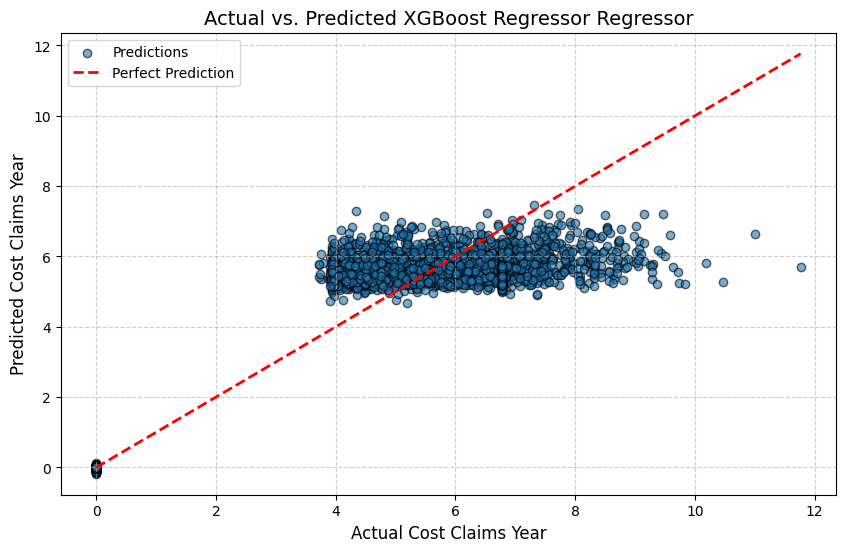

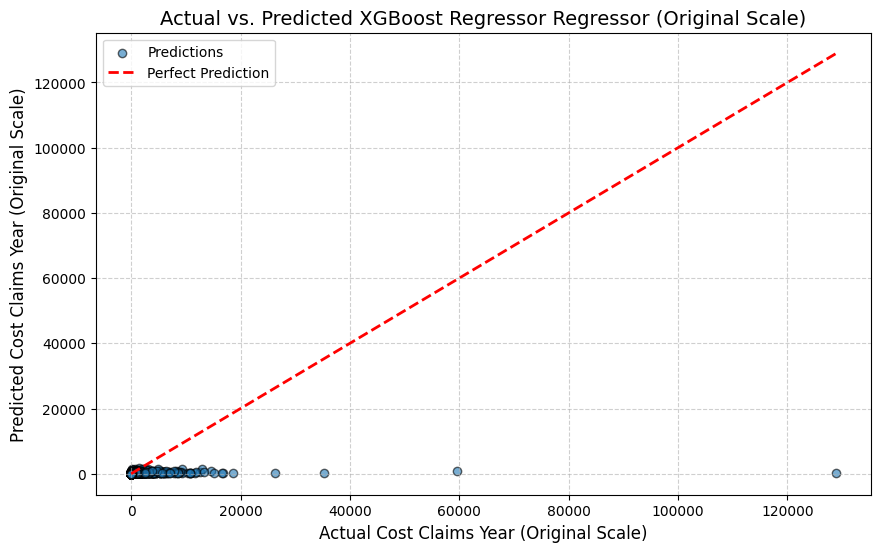

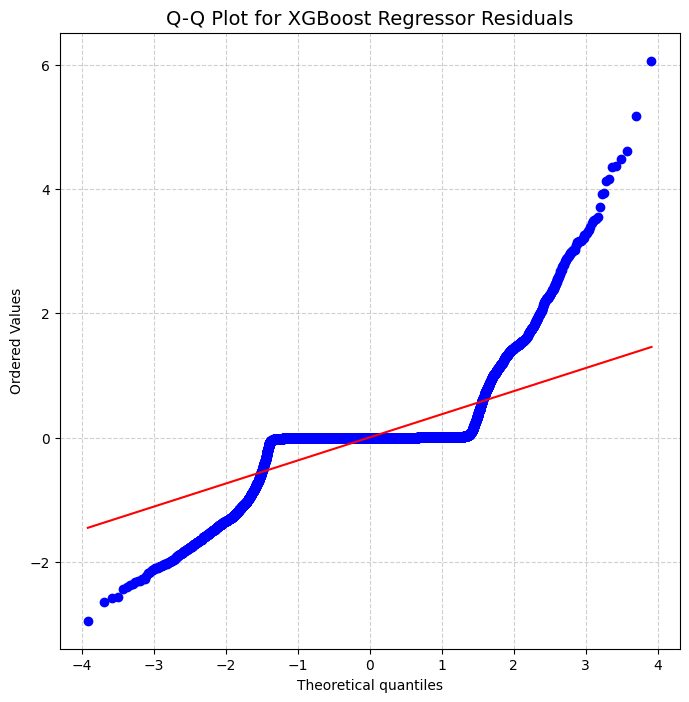

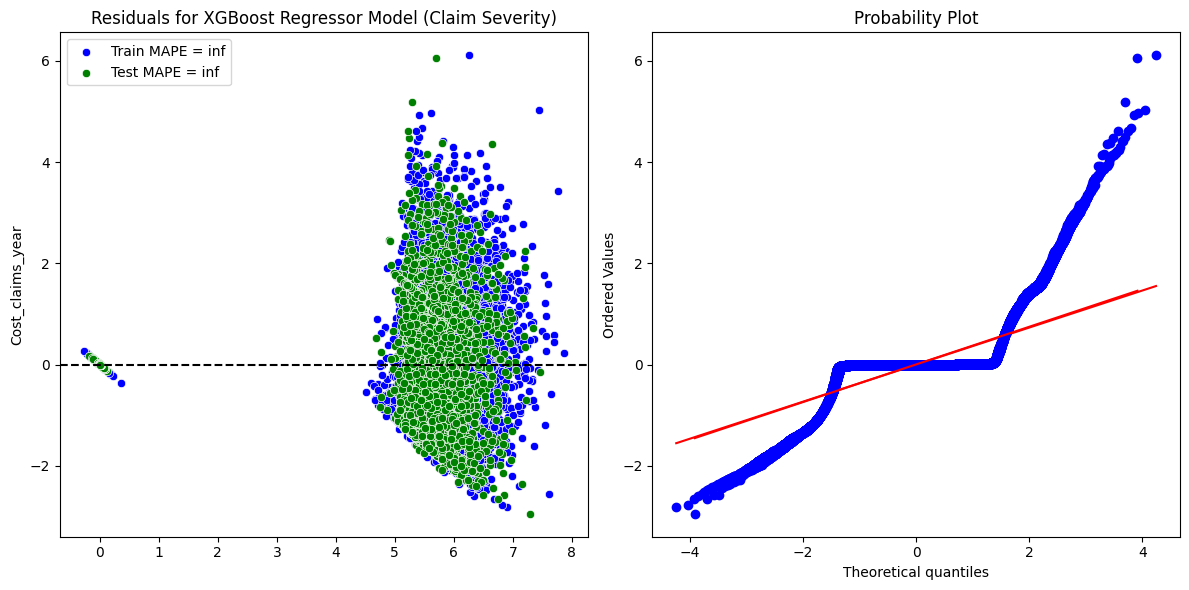

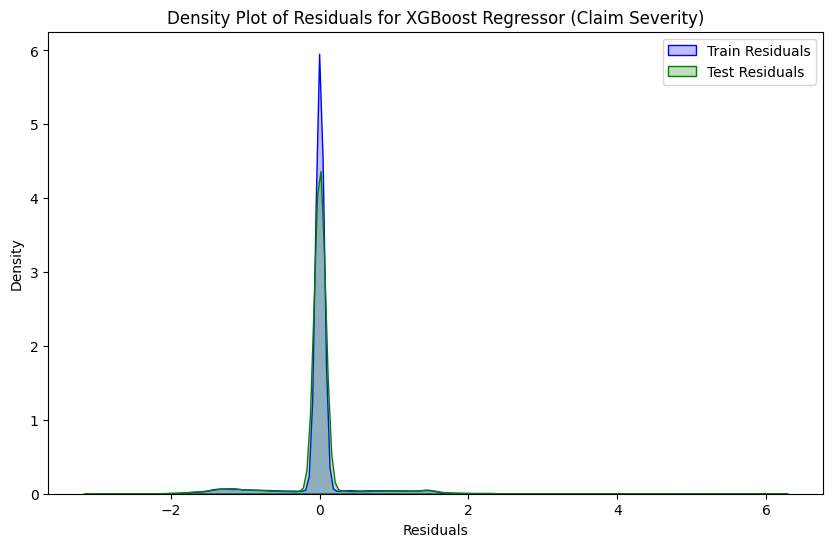

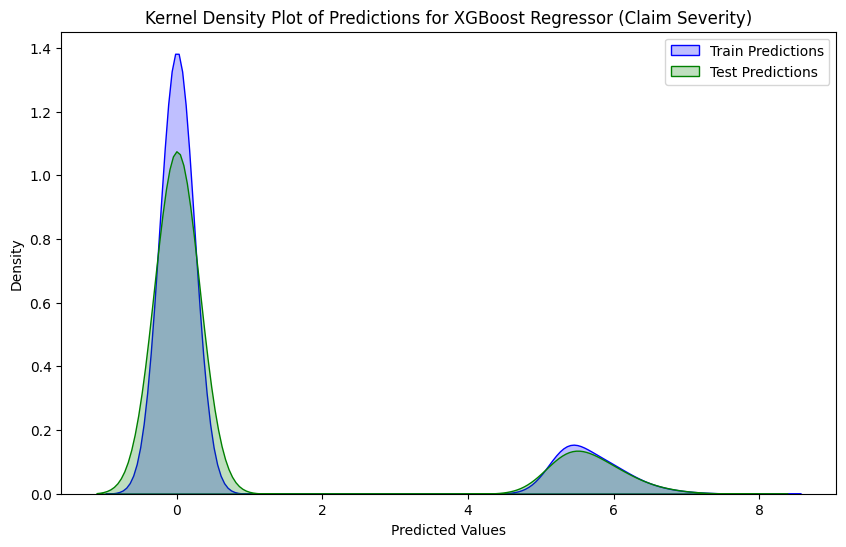

High leverage points IDs: [33079, 22883, 31254, 42224, 45991, 50561, 19931, 4670, 42224, 28977, 40886, 7722, 37458, 41143, 16677, 15617, 1400, 11486, 28545, 16884, 48278, 27126, 35740, 46095, 2569, 44062, 30508, 11215, 23463, 51389, 51263, 16680, 18848, 9228, 37656, 27713, 13814, 9286, 10479, 9183, 6238, 32759, 19990, 4610, 41649, 27739, 23070, 945, 22230, 51424, 5529, 34754, 5245, 4511, 14515, 39867, 6169, 2569, 32165, 5529, 23079, 19585, 24192, 14035, 5795, 26681, 22790, 31241, 9258, 36318, 48330, 44603, 18797, 41318, 52589, 13980, 18870, 2978, 46718, 26010, 34229, 25595, 45079, 16677, 40675, 14705, 42786, 32597, 46929, 105, 14361, 21776, 13746, 21215, 28573, 24676, 38609, 16310, 34888, 37956, 23759, 48278, 36694, 4056, 28542, 11008, 6858, 25461, 6218, 1400, 24349, 11798, 3226, 42184, 4099, 15617, 11161, 7226, 51023, 6795, 15622, 26697, 27427, 46472, 16895, 36470]
High Cook's distance points IDs: [8111, 44649, 36425, 29336, 3379, 3462, 19038, 7364, 25818, 48577, 51017, 25053, 23381, 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Define the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [300],
    'max_depth': [3],
    'learning_rate': [0.05],
    'subsample': [0.8, 1.0, 1.2],
    'colsample_bytree': [0.8, 1.0, 1.2]
}

run_model_with_top_features_and_qq_plot(
    df_train=df_train, 
    df_test=df_test, 
    model=model, 
    param_grid=param_grid, 
    model_name="XGBoost Regressor"
)



c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 1 Results:
  Mean Squared Error (MSE): 0.2530
  Mean Absolute Error (MAE): 0.1760


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2754
  Mean Absolute Error (MAE): 0.1848


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2636
  Mean Absolute Error (MAE): 0.1809


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2622
  Mean Absolute Error (MAE): 0.1820


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for Random Forest:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}


Random Forest Cross-Validation Summary:
  Fold 1: MSE = 0.2530, MAE = 0.1760
  Fold 2: MSE = 0.2754, MAE = 0.1848
  Fold 3: MSE = 0.2607, MAE = 0.1794
  Fold 4: MSE = 0.2636, MAE = 0.1809
  Fold 5: MSE = 0.2622, MAE = 0.1820

Random Forest Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2125
Mean Absolute Error (MAE - Training, Log Transformed): 0.1624
R² Score (Training): 0.9568

Random Forest Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2624
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1769
R² Score (Testing): 0.9452
Mean Absolute Percentage Error (MAPE - Training, Original Scale): 1.1745
Mean Absolute Error (MAE - Training, Original Scale): 110.5511
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): 1.4053
Mean Absolute Error (MAE - Testing, Original Scale): 117.4798


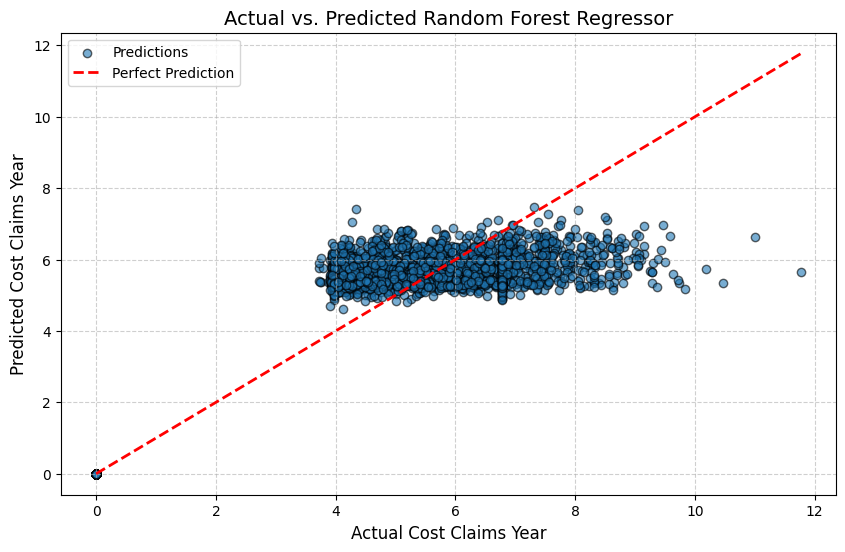

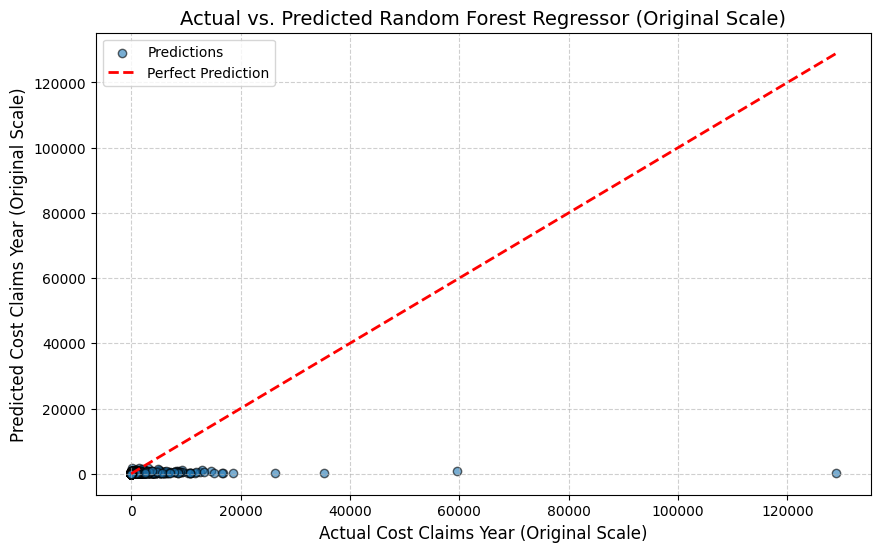

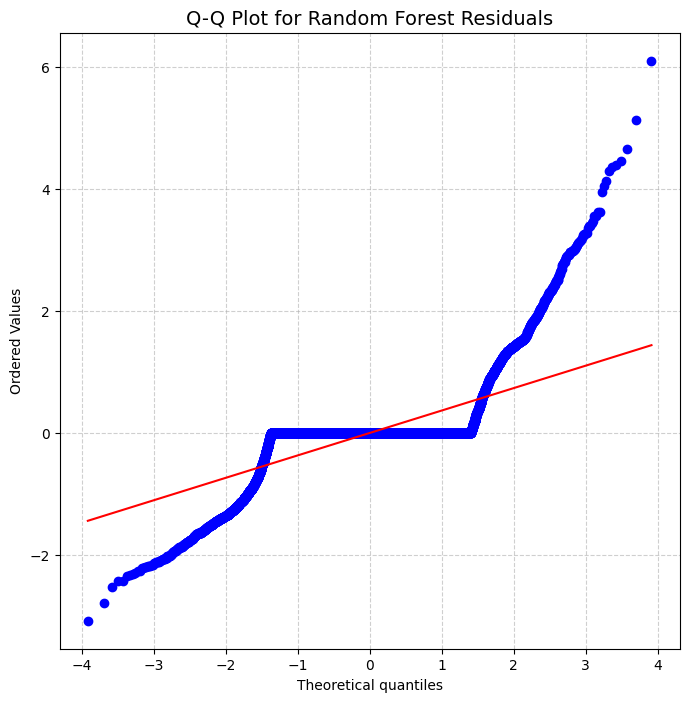

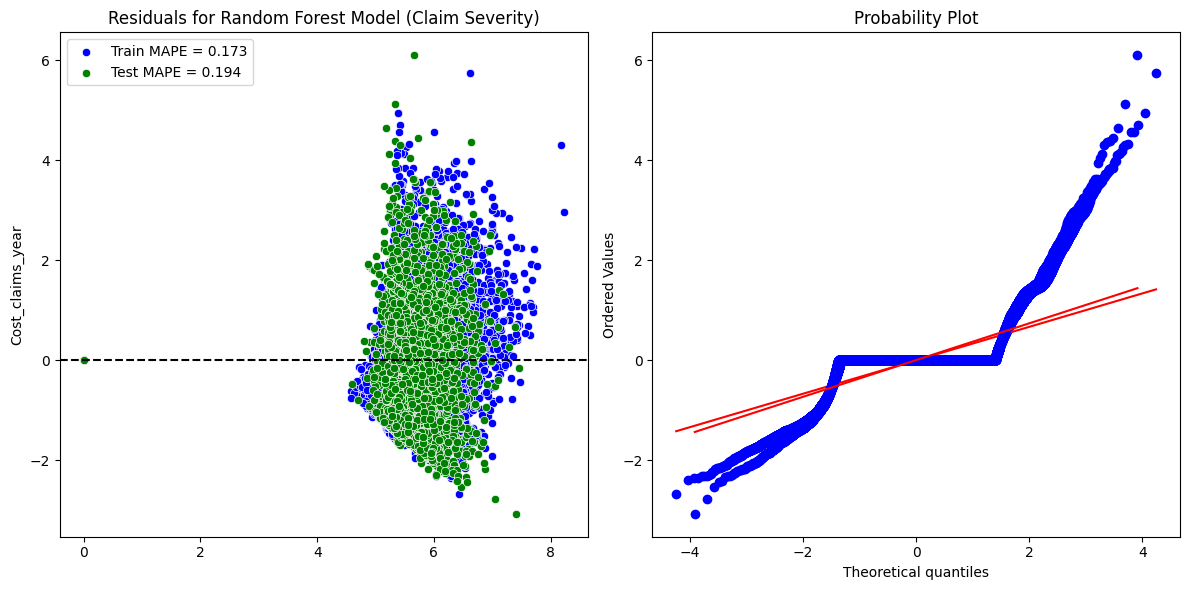

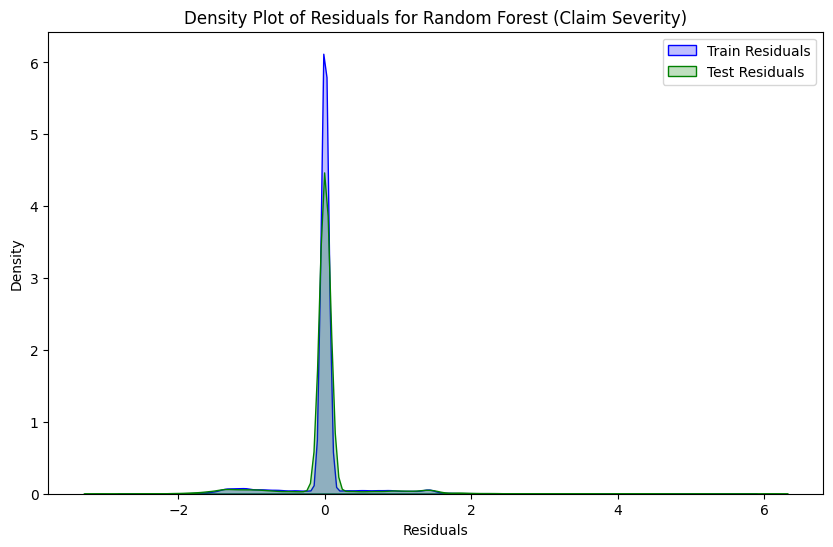

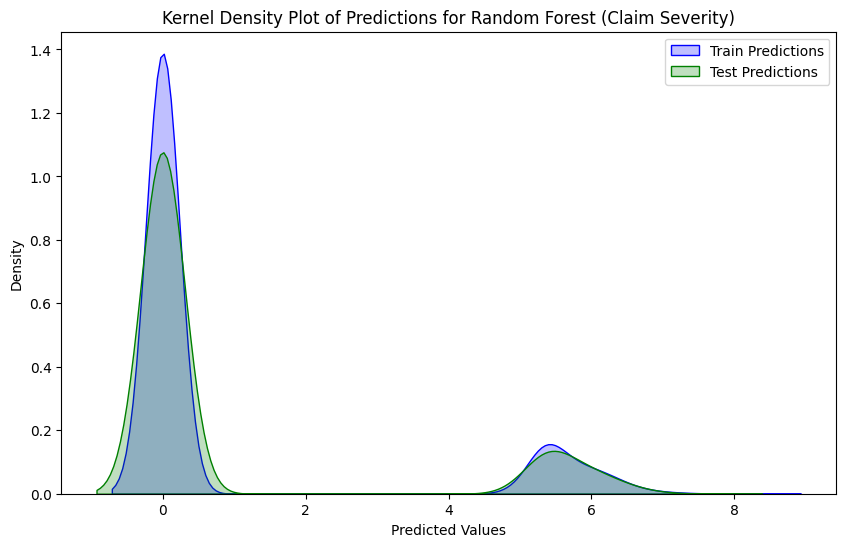

High leverage points IDs: [33079, 22883, 31254, 42224, 45991, 50561, 19931, 4670, 42224, 28977, 40886, 7722, 37458, 41143, 16677, 15617, 1400, 11486, 28545, 16884, 48278, 27126, 35740, 46095, 2569, 44062, 30508, 11215, 23463, 51389, 51263, 16680, 18848, 9228, 37656, 27713, 13814, 9286, 10479, 9183, 6238, 32759, 19990, 4610, 41649, 27739, 23070, 945, 22230, 51424, 5529, 34754, 5245, 4511, 14515, 39867, 6169, 2569, 32165, 5529, 23079, 19585, 24192, 14035, 5795, 26681, 22790, 31241, 9258, 36318, 48330, 44603, 18797, 41318, 52589, 13980, 18870, 2978, 46718, 26010, 34229, 25595, 45079, 16677, 40675, 14705, 42786, 32597, 46929, 105, 14361, 21776, 13746, 21215, 28573, 24676, 38609, 16310, 34888, 37956, 23759, 48278, 36694, 4056, 28542, 11008, 6858, 25461, 6218, 1400, 24349, 11798, 3226, 42184, 4099, 15617, 11161, 7226, 51023, 6795, 15622, 26697, 27427, 46472, 16895, 36470]
High Cook's distance points IDs: [8111, 36425, 42108, 29336, 3379, 3462, 26389, 19038, 7364, 25818, 51017, 25053, 23381, 

RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42)

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [200],
    'max_depth': [10],
    'min_samples_split': [10],
    'min_samples_leaf': [4]
}

run_model_with_top_features_and_qq_plot(
    df_train=df_train, 
    df_test=df_test, 
    model=rf_model, 
    param_grid=rf_param_grid, 
    model_name="Random Forest"
)



c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fold 1 Results:
  Mean Squared Error (MSE): 0.2542
  Mean Absolute Error (MAE): 0.1799


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 2 Results:
  Mean Squared Error (MSE): 0.2737
  Mean Absolute Error (MAE): 0.1873


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...

Fold 4 Results:
  Mean Squared Error (MSE): 0.2599
  Mean Absolute Error (MAE): 0.1826


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fold 5 Results:
  Mean Squared Error (MSE): 0.2609
  Mean Absolute Error (MAE): 0.1845


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters from Grid Search for Gradient Boosting:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.05}


Gradient Boosting Cross-Validation Summary:
  Fold 1: MSE = 0.2542, MAE = 0.1799
  Fold 2: MSE = 0.2737, MAE = 0.1873
  Fold 3: MSE = 0.2563, MAE = 0.1811
  Fold 4: MSE = 0.2599, MAE = 0.1826
  Fold 5: MSE = 0.2609, MAE = 0.1845

Gradient Boosting Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.2520
Mean Absolute Error (MAE - Training, Log Transformed): 0.1795
R² Score (Training): 0.9487

Gradient Boosting Model Evaluation on Test Set:
Mean Squared Error (MSE - Testing): 0.2632
Mean Absolute Error (MAE - Testing, Log Transformed): 0.1798
R² Score (Testing): 0.9450
Mean Absolute Percentage Error (MAPE - Training, Original Scale): inf
Mean Absolute Error (MAE - Training, Original Scale): 116.5060
Mean Absolute Percentage Error (MAPE - Testing, Original Scale): inf
Mean Absolute Error (MAE - Testing

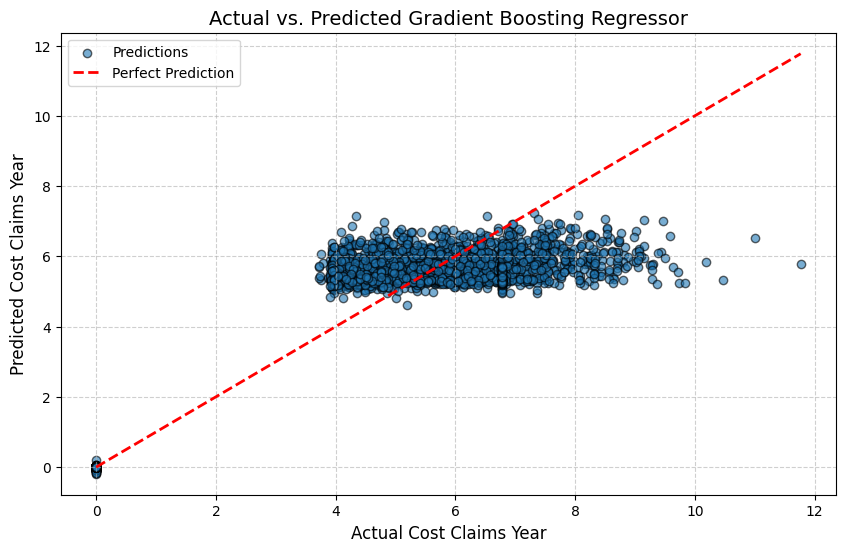

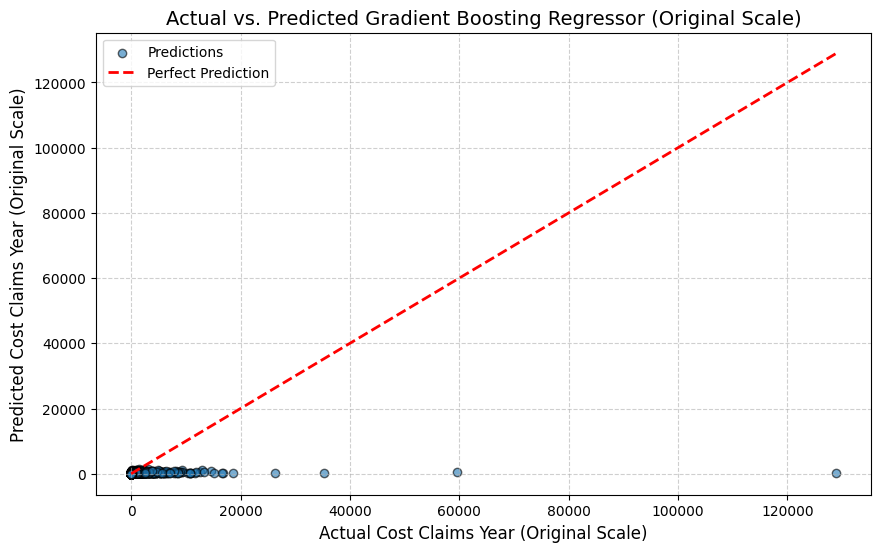

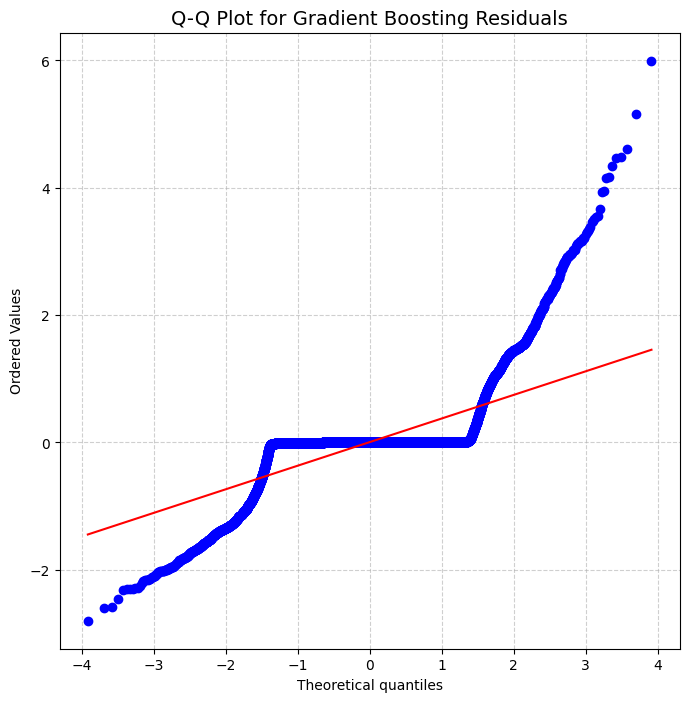

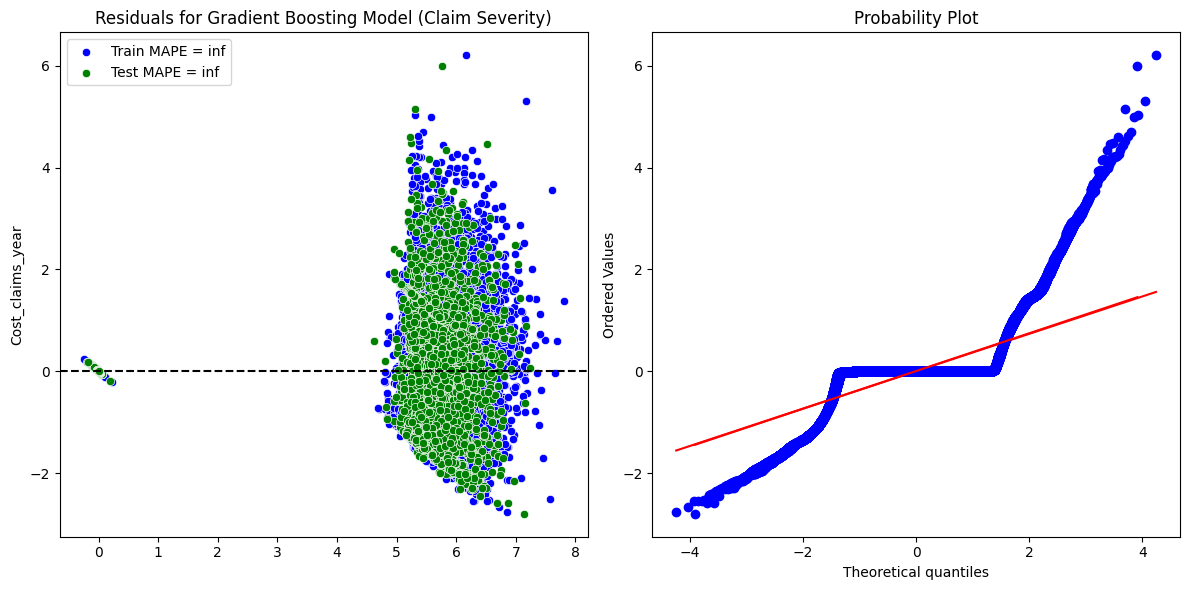

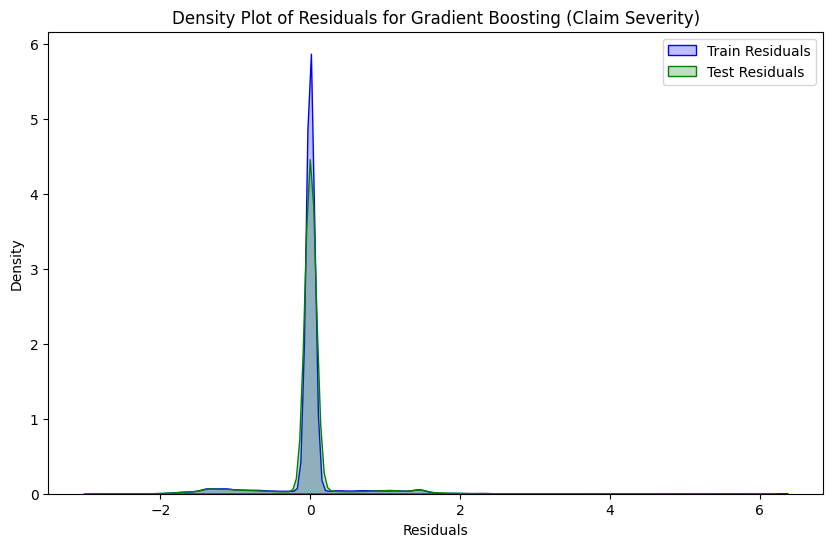

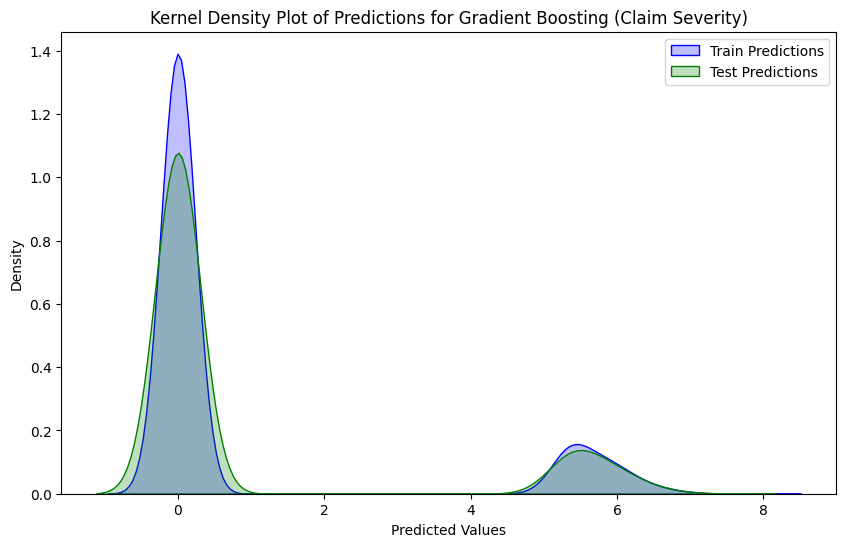

High leverage points IDs: [33079, 22883, 31254, 42224, 45991, 50561, 19931, 4670, 42224, 28977, 40886, 7722, 37458, 41143, 16677, 15617, 1400, 11486, 28545, 16884, 48278, 27126, 35740, 46095, 2569, 44062, 30508, 11215, 23463, 51389, 51263, 16680, 18848, 9228, 37656, 27713, 13814, 9286, 10479, 9183, 6238, 32759, 19990, 4610, 41649, 27739, 23070, 945, 22230, 51424, 5529, 34754, 5245, 4511, 14515, 39867, 6169, 2569, 32165, 5529, 23079, 19585, 24192, 14035, 5795, 26681, 22790, 31241, 9258, 36318, 48330, 44603, 18797, 41318, 52589, 13980, 18870, 2978, 46718, 26010, 34229, 25595, 45079, 16677, 40675, 14705, 42786, 32597, 46929, 105, 14361, 21776, 13746, 21215, 28573, 24676, 38609, 16310, 34888, 37956, 23759, 48278, 36694, 4056, 28542, 11008, 6858, 25461, 6218, 1400, 24349, 11798, 3226, 42184, 4099, 15617, 11161, 7226, 51023, 6795, 15622, 26697, 27427, 46472, 16895, 36470]
High Cook's distance points IDs: [8111, 36425, 29336, 3379, 3462, 19038, 7364, 25818, 48577, 51017, 25053, 23381, 29847, 

GradientBoostingRegressor(learning_rate=0.05, min_samples_split=10,
                          n_estimators=200, random_state=42)

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

# Define Gradient Boosting Model and its hyperparameter grid
gbm_model = GradientBoostingRegressor(random_state=42)
gbm_param_grid = {
    'n_estimators': [200],
    'learning_rate': [0.05],
    'max_depth': [3],
    'min_samples_split': [10],
    'min_samples_leaf': [1, 2, 4]
}

# Run the model with the specified function
run_model_with_top_features_and_qq_plot(
    df_train=df_train, 
    df_test=df_test, 
    model=gbm_model, 
    param_grid=gbm_param_grid, 
    model_name="Gradient Boosting"
)
# 14
